<a href="https://colab.research.google.com/github/twillixa/PPS/blob/main/Main_1_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpInteger,
    lpSum, value, PULP_CBC_CMD
)

##Data loading

In [2]:





REPO_URL = "https://github.com/twillixa/PPS"
CSV_FILENAME = "Demand_data.csv"
RAW_URL = f"https://raw.githubusercontent.com/twillixa/PPS/main/{CSV_FILENAME}"

demand_df = pd.read_csv(RAW_URL)
demand_df.columns = [
    "Day",
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Lubricant Oil",
    "Diamond Marker",
    "Gold Crown",
]

component_names = [c for c in demand_df.columns if c != "Day"]

# Per-component summary statistics (daily)
demand_stats = {}
for comp in component_names:
    series = demand_df[comp]
    demand_stats[comp] = {
        "mean_daily": round(series.mean(), 4),
        "std_daily":  round(series.std(ddof=1), 4),
        "min_daily":  int(series.min()),
        "max_daily":  int(series.max()),
        "total":      int(series.sum()),
    }

print(f"Loaded '{CSV_FILENAME}' from {REPO_URL}")
print(f"{len(demand_df)} days, {len(component_names)} components\n")
print(f"  {'Component':<20} {'Mean/day':>9} {'Std/day':>9} {'Min':>5} {'Max':>5} {'Total':>7}")
print(f"  {'-'*58}")
for comp, s in demand_stats.items():
    print(f"  {comp:<20} {s['mean_daily']:>9.2f} {s['std_daily']:>9.2f} "
          f"{s['min_daily']:>5} {s['max_daily']:>5} {s['total']:>7}")

Loaded 'Demand_data.csv' from https://github.com/twillixa/PPS
365 days, 7 components

  Component             Mean/day   Std/day   Min   Max   Total
  ----------------------------------------------------------
  3235 Movement            14.26      3.56     5    25    5205
  Oystersteel Case         15.18      4.28     4    29    5540
  Sapphire Crystal         14.21      3.59     4    25    5187
  Jubilee Bracelet          8.02      0.99     5    12    2926
  Lubricant Oil           150.72     41.18    40   298   55014
  Diamond Marker           47.81      5.09    35    63   17449
  Gold Crown                8.01      3.03     0    17    2922


In [3]:

# ------------------------------------------------------------
# AGGREGATE PLANNING PARAMETERS (Table 1)
# ------------------------------------------------------------

planning_horizon = 12  # months (January to December)

# Workforce & Production
initial_workers = 90          # workers at start of January
production_rate = 10          # watches per worker per month

# Inventory
starting_inventory = 900      # watches (beginning of January)
ending_inventory_target = 1000  # watches (end of December)
holding_cost = 1000           # CHF per watch per month

# Labor Costs
regular_wage = 7000           # CHF per worker per month
hiring_cost = 50000           # CHF per worker hired
layoff_cost = 25000           # CHF per worker laid off

# Overtime
overtime_allowance = 0.20     # up to 20% extra capacity
overtime_cost_multiplier = 2  # 2x regular wage
overtime_months = [3, 5, 9, 12]  # March, May, September, December

# Subcontracting
subcontracting_limit = 300    # watches per month (max)
subcontracting_cost = 15000   # CHF per watch
subcontracting_months = [6, 7, 10, 12]  # June, July, October, December

# Derived: overtime cost per worker per month (when overtime is used)
overtime_cost_per_worker = regular_wage * overtime_cost_multiplier  # CHF

# ------------------------------------------------------------
# FORECASTED MONTHLY DEMAND (Table 2)
# ------------------------------------------------------------

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = {
    "Jan": 900,
    "Feb": 950,
    "Mar": 1200,
    "Apr": 1050,
    "May": 1100,
    "Jun": 1300,
    "Jul": 1250,
    "Aug": 1100,
    "Sep": 1300,
    "Oct": 1450,
    "Nov": 1500,
    "Dec": 1700,
}

demand_list = [demand[m] for m in months]
total_annual_demand = sum(demand_list)  # total watches needed

# ------------------------------------------------------------
# INVENTORY MANAGEMENT PARAMETERS (Table 3, week 4 slide 19)
# ------------------------------------------------------------
# Components for Aurelius SA watches
# Keys: lead_time (days), holding_cost (CHF/unit/month),
#       ordering_cost (CHF), shelf_life (days), supplier

components = {
    "3235 Movement": {
        "lead_time_days": 60,
        "holding_cost_per_unit_month": 1200,  # CHF/unit/month
        "ordering_cost": 9000,                # CHF per order
        "shelf_life_days": 365,
        "supplier": "Supplier",
    },
    "Oystersteel Case": {
        "lead_time_days": 45,
        "holding_cost_per_unit_month": 400,
        "ordering_cost": 7000,
        "shelf_life_days": 505,
        "supplier": "Internal",
    },
    "Sapphire Crystal": {
        "lead_time_days": 30,
        "holding_cost_per_unit_month": 200,
        "ordering_cost": 4000,
        "shelf_life_days": 365,
        "supplier": "Internal",
    },
    "Jubilee Bracelet": {
        "lead_time_days": 35,
        "holding_cost_per_unit_month": 220,
        "ordering_cost": 3500,
        "shelf_life_days": 1460,
        "supplier": "Internal",
    },
    "Lubricant Oil": {
        "lead_time_days": 14,
        "holding_cost_per_unit_month": 50,
        "ordering_cost": 1000,
        "shelf_life_days": 730,
        "supplier": "Supplier DE",
    },
    "Diamond Marker": {
        "lead_time_days": 21,
        "holding_cost_per_unit_month": 900,
        "ordering_cost": 6000,
        "shelf_life_days": 1825,
        "supplier": "Supplier CH",
    },
    "Gold Crown": {
        "lead_time_days": 40,
        "holding_cost_per_unit_month": 350,
        "ordering_cost": 5000,
        "shelf_life_days": 730,
        "supplier": "Supplier CH",
    },
}

# ------------------------------------------------------------
# SUMMARY PRINTOUT
# ------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 55)
    print("AURELIUS SA — PROJECT PART 1 DATA SUMMARY")
    print("=" * 55)

    print("\n--- Aggregate Planning ---")
    print(f"  Planning horizon      : {planning_horizon} months")
    print(f"  Initial workers       : {initial_workers}")
    print(f"  Production rate       : {production_rate} watches/worker/month")
    print(f"  Starting inventory    : {starting_inventory} watches")
    print(f"  Ending target         : {ending_inventory_target} watches")
    print(f"  Holding cost          : {holding_cost} CHF/watch/month")
    print(f"  Regular wage          : {regular_wage} CHF/worker/month")
    print(f"  Hiring cost           : {hiring_cost} CHF/worker")
    print(f"  Layoff cost           : {layoff_cost} CHF/worker")
    print(f"  Overtime allowance    : {overtime_allowance*100:.0f}% extra capacity")
    print(f"  Overtime months       : {[months[m-1] for m in overtime_months]}")
    print(f"  Subcontracting limit  : {subcontracting_limit} watches/month")
    print(f"  Subcontracting cost   : {subcontracting_cost} CHF/watch")
    print(f"  Subcontracting months : {[months[m-1] for m in subcontracting_months]}")

    print("\n--- Monthly Demand Forecast ---")
    print(f"  {'Month':<6} {'Demand':>8}")
    print(f"  {'-'*16}")
    for m, d in demand.items():
        print(f"  {m:<6} {d:>8}")
    print(f"  {'-'*16}")
    print(f"  {'TOTAL':<6} {total_annual_demand:>8}")

    print("\n--- Inventory Components ---")
    print(f"  {'Component':<20} {'LT(d)':>6} {'Hold':>6} {'Order':>7} "
          f"{'Shelf(d)':>9} {'Supplier':<12}")
    print(f"  {'-'*65}")
    for name, p in components.items():
        print(f"  {name:<20} {p['lead_time_days']:>6} "
              f"{p['holding_cost_per_unit_month']:>6} "
              f"{p['ordering_cost']:>7} "
              f"{p['shelf_life_days']:>9} "
              f"{p['supplier']:<12}")

    print("\nData loaded successfully. Ready for analysis.")


AURELIUS SA — PROJECT PART 1 DATA SUMMARY

--- Aggregate Planning ---
  Planning horizon      : 12 months
  Initial workers       : 90
  Production rate       : 10 watches/worker/month
  Starting inventory    : 900 watches
  Ending target         : 1000 watches
  Holding cost          : 1000 CHF/watch/month
  Regular wage          : 7000 CHF/worker/month
  Hiring cost           : 50000 CHF/worker
  Layoff cost           : 25000 CHF/worker
  Overtime allowance    : 20% extra capacity
  Overtime months       : ['Mar', 'May', 'Sep', 'Dec']
  Subcontracting limit  : 300 watches/month
  Subcontracting cost   : 15000 CHF/watch
  Subcontracting months : ['Jun', 'Jul', 'Oct', 'Dec']

--- Monthly Demand Forecast ---
  Month    Demand
  ----------------
  Jan         900
  Feb         950
  Mar        1200
  Apr        1050
  May        1100
  Jun        1300
  Jul        1250
  Aug        1100
  Sep        1300
  Oct        1450
  Nov        1500
  Dec        1700
  ----------------
  TOTAL    

#**Part 1**

##Model 1

In [4]:
# ── Model 1: Base MILP with strategy switch (chase / level) ──────────────────



def solve_model1(strategy="level", verbose=False):
    """
    Model 1 – no overtime, no subcontracting.

    strategy : "level" → workforce is fixed to a single constant W*
               "chase" → workforce can change freely each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model1_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    # chase: P[t] free each month  |  level: all P[t] forced equal via W_star
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T          # same variable reused → forces constant workforce
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    P = [LpVariable(f"P_{t}", lowBound=0) for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker * W[t] for t in range(T))
      + lpSum(hiring_cost     * H[t] for t in range(T))
      + lpSum(layoff_cost     * F[t] for t in range(T))
      + lpSum(holding_cost    * I[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]

        # Workforce balance: always enforced (for level, H/F only fire at t=0 if needed)
        prob += W[t] == prev_W + H[t] - F[t],                          f"workforce_{t}"
        # Production/Inventory balance
        prob += I[t] == prev_I + P[t] - demand_list[t], f"inventory_{t}"
        #Max production
        prob += P[t] <= prod_per_worker * W[t], f"prod_cap_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t]))) for t in range(T)]
    hired     = [int(round(value(H[t]))) for t in range(T)]
    fired     = [int(round(value(F[t]))) for t in range(T)]
    inventory = [value(I[t])             for t in range(T)]

    wage_c   = [wage_per_worker * workers[t]   for t in range(T)]
    hire_c   = [hiring_cost     * hired[t]     for t in range(T)]
    layoff_c = [layoff_cost     * fired[t]     for t in range(T)]
    inv_c    = [holding_cost    * inventory[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Produced": [value(P[t]) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(inv_c),
    }

    return df, summary


In [5]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

# Global variables used by solve_model1 (and all subsequent models)
T               = planning_horizon
I0              = starting_inventory
I_T             = ending_inventory_target
W0              = initial_workers
prod_per_worker = production_rate
wage_per_worker = regular_wage
# Note: hiring_cost, layoff_cost, holding_cost, subcontracting_cost already defined above
MONTH_NAMES     = months
demand_list     = [demand[m] for m in months]

for strat in ("level", "chase"):
    df, s = solve_model1(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 1 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 1 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,161,71,0,0,900,0,1127000,3550000,0,0,"4,677,000"
1,Feb,161,0,0,950,950,0,1127000,0,0,0,"1,127,000"
2,Mar,161,0,0,"1,200",1200,0,1127000,0,0,0,"1,127,000"
3,Apr,161,0,0,"1,050",1050,0,1127000,0,0,0,"1,127,000"
4,May,161,0,0,"1,100",1100,0,1127000,0,0,0,"1,127,000"
5,Jun,161,0,0,"1,300",1300,0,1127000,0,0,0,"1,127,000"
6,Jul,161,0,0,"1,250",1250,0,1127000,0,0,0,"1,127,000"
7,Aug,161,0,0,"1,610",1100,510,1127000,0,0,"510,000","1,637,000"
8,Sep,161,0,0,"1,610",1300,820,1127000,0,0,"820,000","1,947,000"
9,Oct,161,0,0,"1,610",1450,980,1127000,0,0,"980,000","2,107,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      13,524,000
  Total Hiring        :       3,550,000
  Total Layoff        :               0
  Total Inventory     :       4,400,000
  Grand Total         :      21,474,000

════════════════════════════════════════════════════════════
  MODEL 1 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,900,0,630000,0,0,0,"630,000"
1,Feb,100,10,0,"1,000",950,50,700000,500000,0,"50,000","1,250,000"
2,Mar,115,15,0,"1,150",1200,0,805000,750000,0,0,"1,555,000"
3,Apr,115,0,0,"1,050",1050,0,805000,0,0,0,"805,000"
4,May,115,0,0,"1,150",1100,50,805000,0,0,"50,000","855,000"
5,Jun,125,10,0,"1,250",1300,0,875000,500000,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",1250,0,875000,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",1100,0,875000,0,0,0,"875,000"
8,Sep,131,6,0,"1,310",1300,10,917000,300000,0,"10,000","1,227,000"
9,Oct,188,57,0,"1,880",1450,440,1316000,2850000,0,"440,000","4,606,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      11,235,000
  Total Hiring        :       4,900,000
  Total Layoff        :               0
  Total Inventory     :       2,370,000
  Grand Total         :      18,505,000


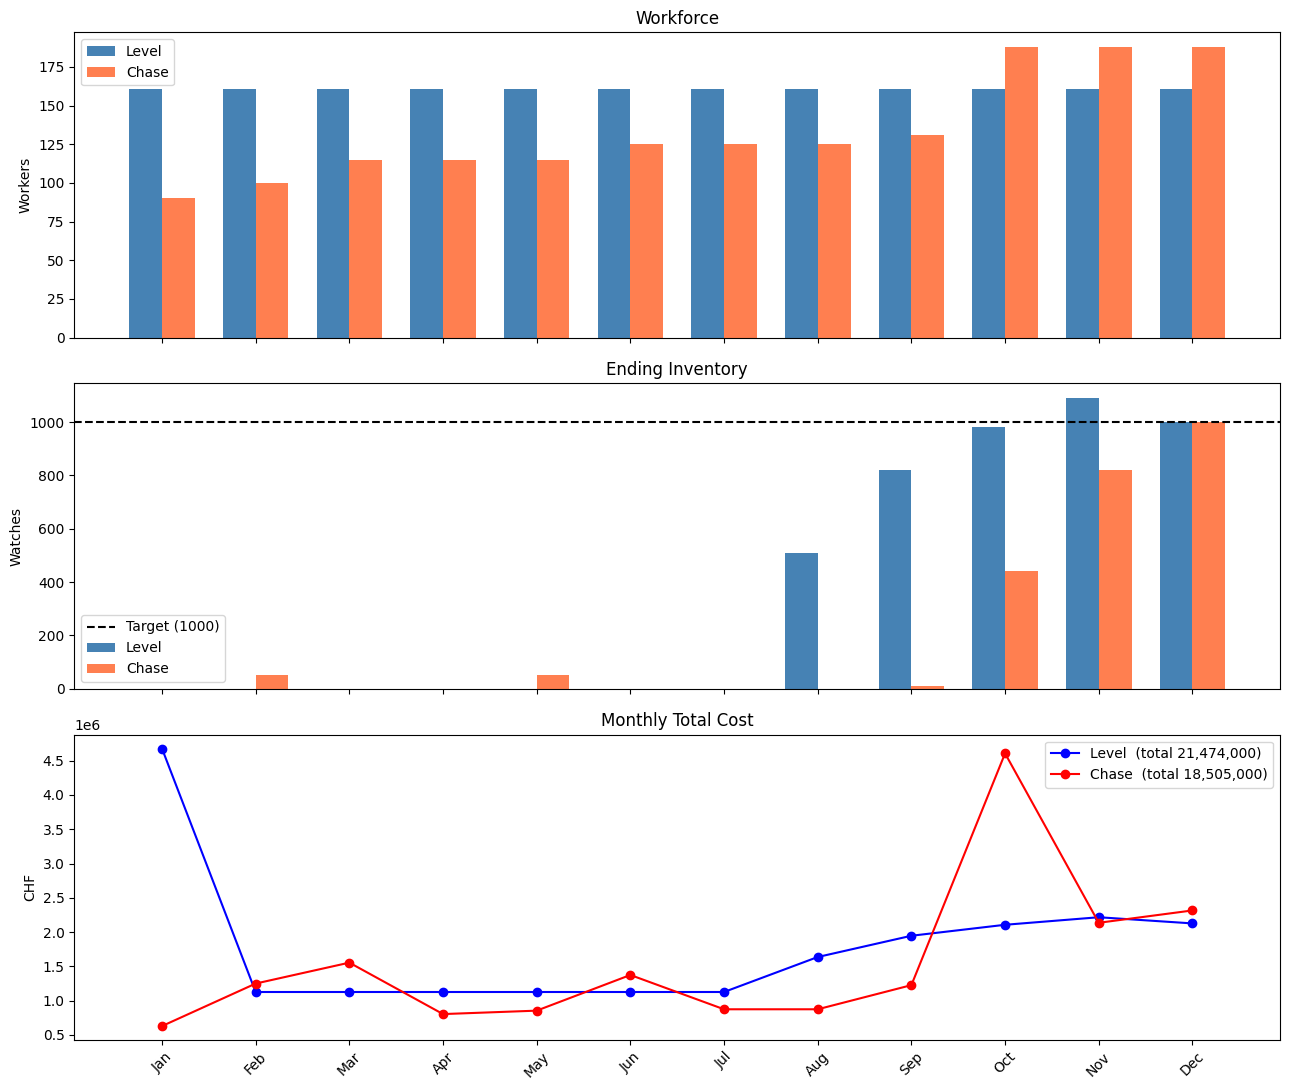

In [6]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model1(strategy="level")
df_chase, s_chase = solve_model1(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 2

In [7]:
# ── Model 2: MILP with overtime (chase / level) ───────────────────────────────

def solve_model2(strategy="level", verbose=False):
    """
    Model 2 – overtime allowed in Mar, May, Sep, Dec (no subcontracting).

    Decision variables:
        W[t]  : workforce at end of month t
        P[t]  : Production at month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (watches, only in overtime months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model2_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    P  = [LpVariable(f"P_{t}", lowBound=0)                 for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]

    # ── Overtime cost: 2× regular wage, charged per extra watch produced ──────
    # Regular rate: prod_per_worker watches/worker/month → 1 watch costs wage/prod_per_worker
    # Overtime rate: 2× that
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker  * W[t]  for t in range(T))
      + lpSum(hiring_cost      * H[t]  for t in range(T))
      + lpSum(layoff_cost      * F[t]  for t in range(T))
      + lpSum(holding_cost     * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch * OT[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]
        month_num = t + 1   # months list is 0-indexed; overtime_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t],  f"workforce_{t}"

        # Inventory balance (regular production + overtime)
        prob += (I[t] == prev_I + P[t] + OT[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        #Capping max production
        prob += P[t] <= prod_per_worker * W[t], f"prod_cap_{t}"

        # Overtime only allowed in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t])))  for t in range(T)]
    hired     = [int(round(value(H[t])))  for t in range(T)]
    fired     = [int(round(value(F[t])))  for t in range(T)]
    overtime  = [value(OT[t])             for t in range(T)]
    inventory = [value(I[t])              for t in range(T)]

    wage_c   = [wage_per_worker   * workers[t]              for t in range(T)]
    hire_c   = [hiring_cost       * hired[t]                for t in range(T)]
    layoff_c = [layoff_cost       * fired[t]                for t in range(T)]
    inv_c    = [holding_cost      * inventory[t]            for t in range(T)]
    ot_c     = [ot_cost_per_watch * overtime[t]             for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Total Prod.":     [value(P[t]) + int(round(overtime[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total OT":        sum(ot_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(inv_c),
    }

    return df, summary

In [8]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model2(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 2 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 2 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,149,59,0,0,0,0,900,0,1043000,2950000,0,0,0,"3,993,000"
1,Feb,149,0,0,950,0,950,950,0,1043000,0,0,0,0,"1,043,000"
2,Mar,149,0,0,"1,200",0,"1,200",1200,0,1043000,0,0,0,0,"1,043,000"
3,Apr,149,0,0,"1,050",0,"1,050",1050,0,1043000,0,0,0,0,"1,043,000"
4,May,149,0,0,"1,100",0,"1,100",1100,0,1043000,0,0,0,0,"1,043,000"
5,Jun,149,0,0,"1,300",0,"1,300",1300,0,1043000,0,0,0,0,"1,043,000"
6,Jul,149,0,0,"1,254",0,"1,254",1250,4,1043000,0,0,0,"4,000","1,047,000"
7,Aug,149,0,0,"1,490",0,"1,490",1100,394,1043000,0,0,0,"394,000","1,437,000"
8,Sep,149,0,0,"1,490",298,"1,788",1300,882,1043000,0,0,"417,200","882,000","2,342,200"
9,Oct,149,0,0,"1,490",0,"1,490",1450,922,1043000,0,0,0,"922,000","1,965,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      12,516,000
  Total Hiring        :       2,950,000
  Total Layoff        :               0
  Total OT            :         834,400
  Total Inventory     :       4,114,000
  Grand Total         :      20,414,400

════════════════════════════════════════════════════════════
  MODEL 2 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,900,0,630000,0,0,0,0,"630,000"
1,Feb,95,5,0,950,0,950,950,0,665000,250000,0,0,0,"915,000"
2,Mar,105,10,0,"1,050",150,"1,200",1200,0,735000,500000,0,"210,000",0,"1,445,000"
3,Apr,105,0,0,"1,050",0,"1,050",1050,0,735000,0,0,0,0,"735,000"
4,May,115,10,0,"1,150",0,"1,150",1100,50,805000,500000,0,0,"50,000","1,355,000"
5,Jun,125,10,0,"1,250",0,"1,250",1300,0,875000,500000,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,"1,250",1250,0,875000,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,"1,100",1100,0,875000,0,0,0,0,"875,000"
8,Sep,132,7,0,"1,318",0,"1,318",1300,18,924000,350000,0,0,"18,000","1,292,000"
9,Oct,176,44,0,"1,760",0,"1,760",1450,328,1232000,2200000,0,0,"328,000","3,760,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,815,000
  Total Hiring        :       4,300,000
  Total Layoff        :               0
  Total OT            :         702,800
  Total Inventory     :       1,984,000
  Grand Total         :      17,801,800


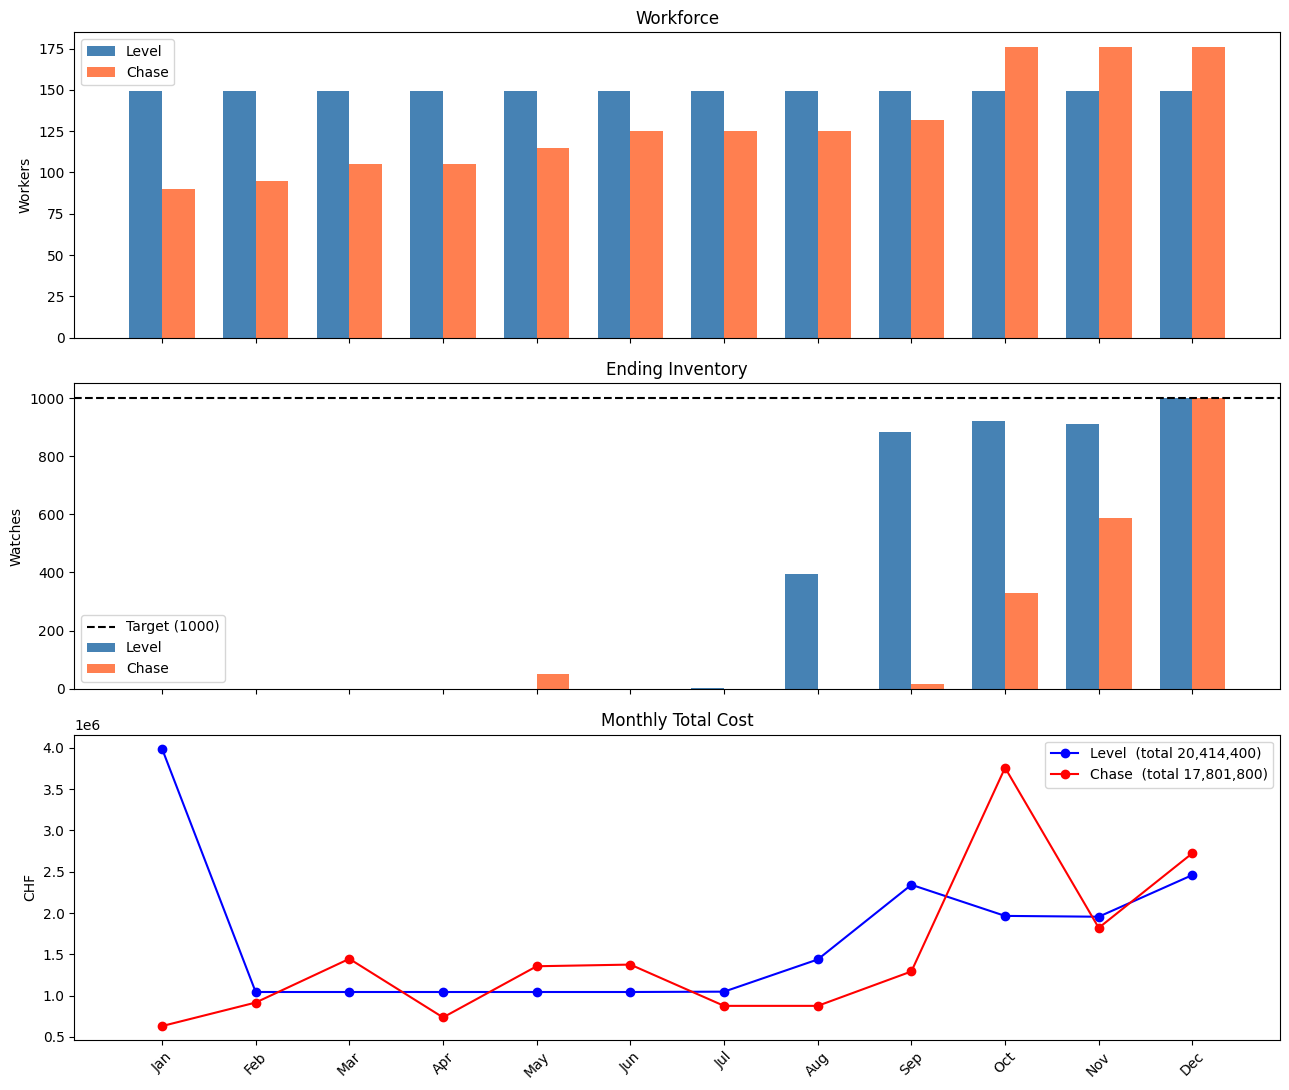

In [9]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model2(strategy="level")
df_chase, s_chase = solve_model2(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 3

In [10]:
# ── Model 3: MILP with subcontracting (chase / level) ────────────────────────

def solve_model3(strategy="level", verbose=False):
    """
    Model 3 – subcontracting allowed in Jun, Jul, Oct, Dec (no overtime).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        P[t]  : Production of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model3_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    S = [LpVariable(f"S_{t}", lowBound=0)                for t in range(T)]
    P = [LpVariable(f"P_{t}", lowBound=0)                for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker    * W[t] for t in range(T))
      + lpSum(hiring_cost        * H[t] for t in range(T))
      + lpSum(layoff_cost        * F[t] for t in range(T))
      + lpSum(holding_cost       * I[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W   = W0 if t == 0 else W[t-1]
        prev_I   = I0 if t == 0 else I[t-1]
        month_num = t + 1   # subcontracting_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular production + subcontracting)
        prob += (I[t] == prev_I + P[t] + S[t] - demand_list[t],
                 f"inventory_{t}")
        #Capping max production
        prob += P[t] <= prod_per_worker * W[t], f"prod_cap_{t}"

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        # Subcontracting only allowed in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers      = [int(round(value(W[t]))) for t in range(T)]
    hired        = [int(round(value(H[t]))) for t in range(T)]
    fired        = [int(round(value(F[t]))) for t in range(T)]
    subcontracted = [value(S[t])            for t in range(T)]
    inventory    = [value(I[t])             for t in range(T)]

    wage_c  = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c  = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c = [layoff_cost        * fired[t]         for t in range(T)]
    inv_c   = [holding_cost        * inventory[t]     for t in range(T)]
    sc_c    = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [value(P[t]) + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":           strategy,
        "Status":             prob.status,
        "Total Wage":         sum(wage_c),
        "Total Hiring":       sum(hire_c),
        "Total Layoff":       sum(layoff_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":    sum(inv_c),
        "Grand Total":        sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [11]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model3(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 3 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 3 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,161,71,0,0,0,0,900,0,1127000,3550000,0,0,0,"4,677,000"
1,Feb,161,0,0,950,0,950,950,0,1127000,0,0,0,0,"1,127,000"
2,Mar,161,0,0,"1,200",0,"1,200",1200,0,1127000,0,0,0,0,"1,127,000"
3,Apr,161,0,0,"1,050",0,"1,050",1050,0,1127000,0,0,0,0,"1,127,000"
4,May,161,0,0,"1,100",0,"1,100",1100,0,1127000,0,0,0,0,"1,127,000"
5,Jun,161,0,0,"1,300",0,"1,300",1300,0,1127000,0,0,0,0,"1,127,000"
6,Jul,161,0,0,"1,250",0,"1,250",1250,0,1127000,0,0,0,0,"1,127,000"
7,Aug,161,0,0,"1,610",0,"1,610",1100,510,1127000,0,0,0,"510,000","1,637,000"
8,Sep,161,0,0,"1,610",0,"1,610",1300,820,1127000,0,0,0,"820,000","1,947,000"
9,Oct,161,0,0,"1,610",0,"1,610",1450,980,1127000,0,0,0,"980,000","2,107,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      13,524,000
  Total Hiring        :       3,550,000
  Total Layoff        :               0
  Total Subcontracting:               0
  Total Inventory     :       4,400,000
  Grand Total         :      21,474,000

════════════════════════════════════════════════════════════
  MODEL 3 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,900,0,630000,0,0,0,0,"630,000"
1,Feb,100,10,0,"1,000",0,"1,000",950,50,700000,500000,0,0,"50,000","1,250,000"
2,Mar,115,15,0,"1,150",0,"1,150",1200,0,805000,750000,0,0,0,"1,555,000"
3,Apr,115,0,0,"1,050",0,"1,050",1050,0,805000,0,0,0,0,"805,000"
4,May,115,0,0,"1,150",0,"1,150",1100,50,805000,0,0,0,"50,000","855,000"
5,Jun,125,10,0,"1,250",0,"1,250",1300,0,875000,500000,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,"1,250",1250,0,875000,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,"1,100",1100,0,875000,0,0,0,0,"875,000"
8,Sep,131,6,0,"1,310",0,"1,310",1300,10,917000,300000,0,0,"10,000","1,227,000"
9,Oct,188,57,0,"1,880",0,"1,880",1450,440,1316000,2850000,0,0,"440,000","4,606,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      11,235,000
  Total Hiring        :       4,900,000
  Total Layoff        :               0
  Total Subcontracting:               0
  Total Inventory     :       2,370,000
  Grand Total         :      18,505,000


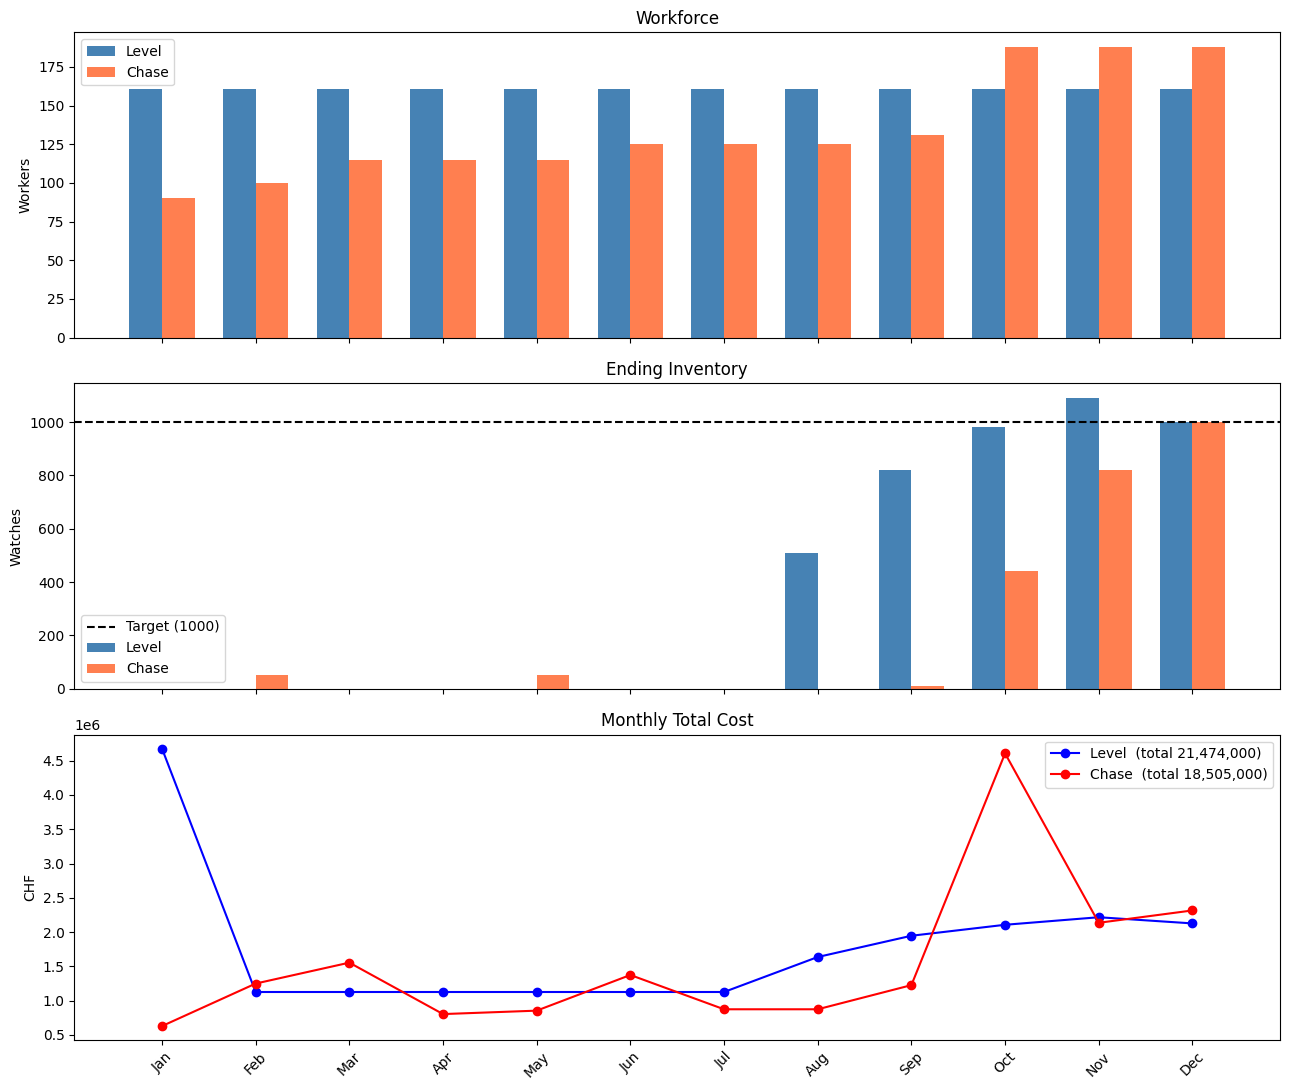

In [12]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model3(strategy="level")
df_chase, s_chase = solve_model3(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 4


In [13]:
# ── Model 4: MILP with overtime + subcontracting (chase / level) ──────────────

def solve_model4(strategy="level", verbose=False):
    """
    Model 4 – overtime (Mar, May, Sep, Dec) + subcontracting (Jun, Jul, Oct, Dec).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        P[t]  : Production of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (only in overtime months)
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model4_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]
    S  = [LpVariable(f"S_{t}",  lowBound=0)                for t in range(T)]
    P  = [LpVariable(f"P_{t}", lowBound=0)                 for t in range(T)]

    # Overtime cost per watch produced
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker     * W[t]  for t in range(T))
      + lpSum(hiring_cost         * H[t]  for t in range(T))
      + lpSum(layoff_cost         * F[t]  for t in range(T))
      + lpSum(holding_cost        * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch   * OT[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t]  for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W    = W0 if t == 0 else W[t-1]
        prev_I    = I0 if t == 0 else I[t-1]
        month_num = t + 1

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular + overtime + subcontracting)
        prob += (I[t] == prev_I + P[t] + OT[t] + S[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        #Capping max production
        prob += P[t] <= prod_per_worker * W[t], f"prod_cap_{t}"

        # Overtime only in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

        # Subcontracting only in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers       = [int(round(value(W[t])))  for t in range(T)]
    hired         = [int(round(value(H[t])))  for t in range(T)]
    fired         = [int(round(value(F[t])))  for t in range(T)]
    overtime      = [value(OT[t])             for t in range(T)]
    subcontracted = [value(S[t])              for t in range(T)]
    inventory     = [value(I[t])              for t in range(T)]

    wage_c    = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c    = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c  = [layoff_cost         * fired[t]         for t in range(T)]
    inv_c     = [holding_cost        * inventory[t]     for t in range(T)]
    ot_c      = [ot_cost_per_watch   * overtime[t]      for t in range(T)]
    sc_c      = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [value(P[t]) + int(round(overtime[t])) + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":             strategy,
        "Status":               prob.status,
        "Total Wage":           sum(wage_c),
        "Total Hiring":         sum(hire_c),
        "Total Layoff":         sum(layoff_c),
        "Total OT":             sum(ot_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":      sum(inv_c),
        "Grand Total":          sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [14]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model4(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 4 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 4 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,149,59,0,0,0,0,0,900,0,1043000,2950000,0,0,0,0,"3,993,000"
1,Feb,149,0,0,950,0,0,950,950,0,1043000,0,0,0,0,0,"1,043,000"
2,Mar,149,0,0,"1,200",0,0,"1,200",1200,0,1043000,0,0,0,0,0,"1,043,000"
3,Apr,149,0,0,"1,050",0,0,"1,050",1050,0,1043000,0,0,0,0,0,"1,043,000"
4,May,149,0,0,"1,100",0,0,"1,100",1100,0,1043000,0,0,0,0,0,"1,043,000"
5,Jun,149,0,0,"1,300",0,0,"1,300",1300,0,1043000,0,0,0,0,0,"1,043,000"
6,Jul,149,0,0,"1,254",0,0,"1,254",1250,4,1043000,0,0,0,0,"4,000","1,047,000"
7,Aug,149,0,0,"1,490",0,0,"1,490",1100,394,1043000,0,0,0,0,"394,000","1,437,000"
8,Sep,149,0,0,"1,490",298,0,"1,788",1300,882,1043000,0,0,"417,200",0,"882,000","2,342,200"
9,Oct,149,0,0,"1,490",0,0,"1,490",1450,922,1043000,0,0,0,0,"922,000","1,965,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      12,516,000
  Total Hiring        :       2,950,000
  Total Layoff        :               0
  Total OT            :         834,400
  Total Subcontracting:               0
  Total Inventory     :       4,114,000
  Grand Total         :      20,414,400

════════════════════════════════════════════════════════════
  MODEL 4 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,0,900,0,630000,0,0,0,0,0,"630,000"
1,Feb,95,5,0,950,0,0,950,950,0,665000,250000,0,0,0,0,"915,000"
2,Mar,105,10,0,"1,050",150,0,"1,200",1200,0,735000,500000,0,"210,000",0,0,"1,445,000"
3,Apr,105,0,0,"1,050",0,0,"1,050",1050,0,735000,0,0,0,0,0,"735,000"
4,May,115,10,0,"1,150",0,0,"1,150",1100,50,805000,500000,0,0,0,"50,000","1,355,000"
5,Jun,125,10,0,"1,250",0,0,"1,250",1300,0,875000,500000,0,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,0,"1,250",1250,0,875000,0,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,0,"1,100",1100,0,875000,0,0,0,0,0,"875,000"
8,Sep,132,7,0,"1,318",0,0,"1,318",1300,18,924000,350000,0,0,0,"18,000","1,292,000"
9,Oct,176,44,0,"1,760",0,0,"1,760",1450,328,1232000,2200000,0,0,0,"328,000","3,760,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,815,000
  Total Hiring        :       4,300,000
  Total Layoff        :               0
  Total OT            :         702,800
  Total Subcontracting:               0
  Total Inventory     :       1,984,000
  Grand Total         :      17,801,800


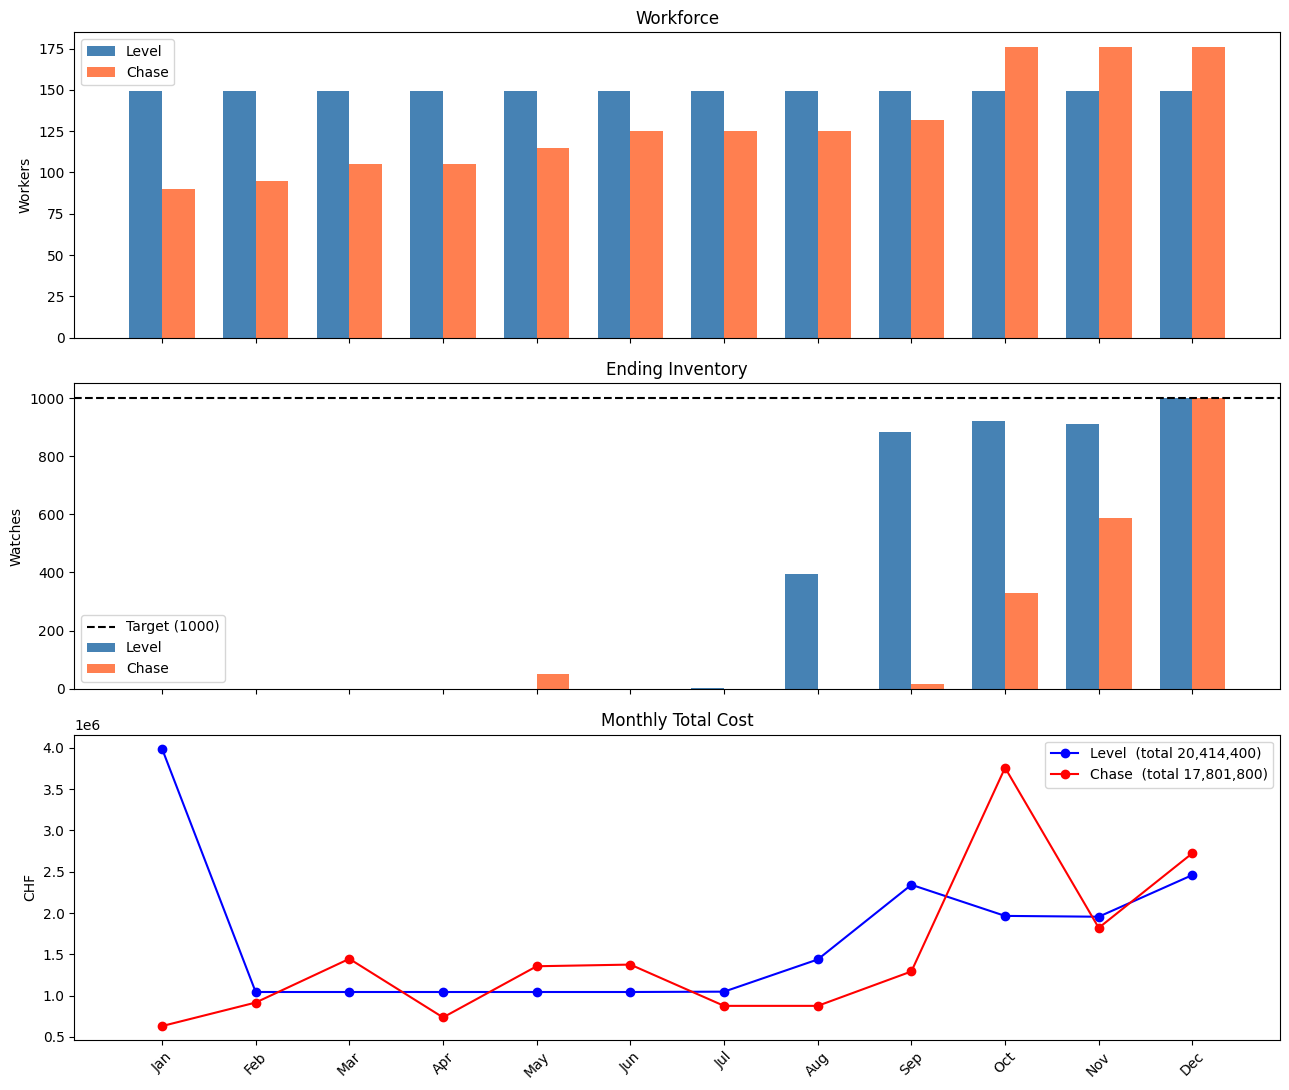

In [15]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model4(strategy="level")
df_chase, s_chase = solve_model4(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Graphs + Cross-Model Comparison


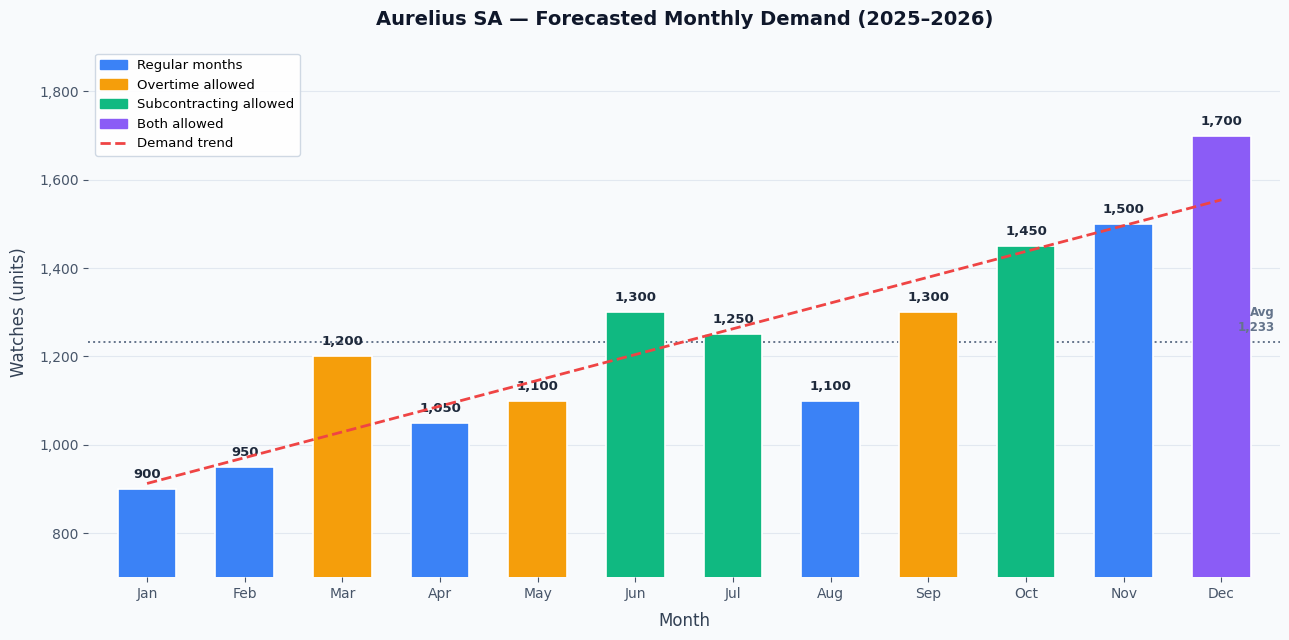

In [16]:
# ── Forecasted Monthly Demand Chart ──────────────────────────────────────────

# Overtime and subcontracting months (1-indexed)
overtime_months_set      = {3, 5, 9, 12}   # Mar, May, Sep, Dec
subcontracting_months_set = {6, 7, 10, 12} # Jun, Jul, Oct, Dec

# Color each bar
colors = []
for i in range(1, 13):
    if i in overtime_months_set and i in subcontracting_months_set:
        colors.append("#8B5CF6")   # purple = both
    elif i in overtime_months_set:
        colors.append("#F59E0B")   # amber = overtime
    elif i in subcontracting_months_set:
        colors.append("#10B981")   # green = subcontracting
    else:
        colors.append("#3B82F6")   # blue = regular

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Bars
bars = ax.bar(MONTH_NAMES, demand_list, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2, zorder=3)

# Trend line
x_num = np.arange(len(MONTH_NAMES))
z = np.polyfit(x_num, demand_list, 1)
p = np.poly1d(z)
ax.plot(MONTH_NAMES, p(x_num), color="#EF4444", linewidth=2,
        linestyle="--", zorder=4, label="Trend")

# Value labels on bars
for bar, val in zip(bars, demand_list):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 18,
            f"{val:,}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color="#1E293B")

# Reference line: average demand
avg = sum(demand_list) / len(demand_list)
ax.axhline(avg, color="#64748B", linewidth=1.4, linestyle=":", zorder=2)
ax.text(11.55, avg + 18, f"Avg\n{avg:,.0f}",
        ha="right", va="bottom", fontsize=8.5,
        color="#64748B", fontweight="bold")

# Axes styling
ax.set_ylim(700, 1900)
ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Month", fontsize=12, color="#334155", labelpad=8)
ax.set_ylabel("Watches (units)", fontsize=12, color="#334155", labelpad=8)
ax.set_title("Aurelius SA — Forecasted Monthly Demand (2025–2026)",
             fontsize=14, fontweight="bold", color="#0F172A", pad=16)

ax.tick_params(colors="#475569", labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color="#3B82F6", label="Regular months"),
    mpatches.Patch(color="#F59E0B", label="Overtime allowed"),
    mpatches.Patch(color="#10B981", label="Subcontracting allowed"),
    mpatches.Patch(color="#8B5CF6", label="Both allowed"),
    plt.Line2D([0], [0], color="#EF4444", linewidth=2,
               linestyle="--", label="Demand trend"),
]
ax.legend(handles=legend_items, loc="upper left",
          frameon=True, framealpha=0.9, fontsize=9.5,
          edgecolor="#CBD5E1")

plt.tight_layout()
plt.show()


=== Grand Total Cost Comparison (CHF) ===


,Model 1 (Base),Model 2 (+OT),Model 3 (+SC),Model 4 (OT+SC)
Strategy,,,,
level,"21,474,000","20,414,400","21,474,000","20,414,400"
chase,"18,505,000","17,801,800","18,505,000","17,801,800"


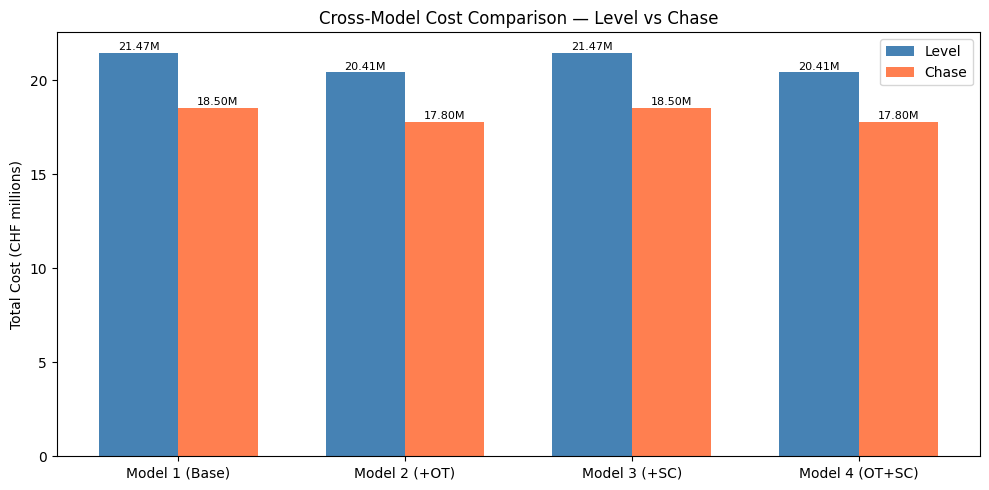

In [17]:
# ── Collect results from all 4 models (both strategies) and compare ──────────

model_results = {}
for strat in ("level", "chase"):
    _, s1 = solve_model1(strategy=strat)
    _, s2 = solve_model2(strategy=strat)
    _, s3 = solve_model3(strategy=strat)
    _, s4 = solve_model4(strategy=strat)
    model_results[strat] = {
        "Model 1 (Base)":        s1["Grand Total"],
        "Model 2 (+OT)":         s2["Grand Total"],
        "Model 3 (+SC)":         s3["Grand Total"],
        "Model 4 (OT+SC)":       s4["Grand Total"],
    }

df_comp = pd.DataFrame(model_results).T
df_comp.index.name = "Strategy"
print("\n=== Grand Total Cost Comparison (CHF) ===")
display(df_comp.style.format("{:,.0f}"))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35
labels = list(model_results["level"].keys())
level_vals = list(model_results["level"].values())
chase_vals = list(model_results["chase"].values())

bars1 = ax.bar(x - w/2, [v/1e6 for v in level_vals], w, color="steelblue", label="Level")
bars2 = ax.bar(x + w/2, [v/1e6 for v in chase_vals],  w, color="coral",     label="Chase")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Total Cost (CHF millions)")
ax.set_title("Cross-Model Cost Comparison — Level vs Chase")
ax.legend()
plt.tight_layout()
plt.show()


## Inventory Management


In [18]:
# ── Inventory Management Parameters ──────────────────────────────────────────
# Component data from Table 3
# holding_cost_per_unit_month: CHF/unit/month  |  ordering_cost: CHF per order
# lead_time_days              |  shelf_life_days

from scipy.stats import norm

SERVICE_LEVEL = 0.98
Z = norm.ppf(SERVICE_LEVEL)           # ≈ 2.054 for 98%
WORKING_DAYS  = 365                   # days per year used for annualisation

print(f"Service level : {SERVICE_LEVEL:.0%}")
print(f"z-score (z_{SERVICE_LEVEL:.0%}): {Z:.4f}")


Service level : 98%
z-score (z_98%): 2.0537


In [19]:
# ── EOQ & Reorder Point Calculations ─────────────────────────────────────────
# For each component we derive:
#   μ_d , σ_d   : mean and std-dev of DAILY demand (from Demand_data.csv)
#   μ_annual    : annualised mean demand (μ_d × 365)
#   h_annual    : annual holding cost   (h_monthly × 12)
#   EOQ         : Economic Order Quantity = sqrt(2 K μ_annual / h_annual)
#   μ_L, σ_L    : mean and std-dev of demand during lead time L
#   Safety Stock: z × σ_L
#   R           : Reorder point = μ_L + Safety Stock
#   Cycle Time  : EOQ / μ_d  (days to consume one order)

inv_records = []

for comp_name, params in components.items():
    series    = demand_df[comp_name]          # daily demand series
    mu_d      = series.mean()
    sigma_d   = series.std(ddof=1)

    mu_annual = mu_d * WORKING_DAYS
    h_annual  = params["holding_cost_per_unit_month"] * 12   # monthly → annual
    K         = params["ordering_cost"]
    L         = params["lead_time_days"]

    # EOQ
    EOQ = np.sqrt(2 * K * mu_annual / h_annual)

    # Lead-time demand statistics
    mu_L    = mu_d * L
    sigma_L = sigma_d * np.sqrt(L)

    # Safety stock & reorder point
    SS = Z * sigma_L
    R  = mu_L + SS

    # Cycle time (days)
    cycle_days = EOQ / mu_d

    # Annual total relevant cost  (ordering + holding cycle stock + holding SS)
    n_orders   = mu_annual / EOQ
    avg_inv    = EOQ / 2 + SS
    ann_cost   = n_orders * K + avg_inv * h_annual

    # Shelf-life check
    shelf_ok = "✓" if cycle_days < params["shelf_life_days"] else "⚠ PERISHABILITY RISK"

    inv_records.append({
        "Component":          comp_name,
        "μ_daily":            round(mu_d,   3),
        "σ_daily":            round(sigma_d,3),
        "Lead Time (days)":   L,
        "EOQ":                round(EOQ,    1),
        "Safety Stock":       round(SS,     1),
        "Reorder Point (R)":  round(R,      1),
        "Cycle Time (days)":  round(cycle_days, 1),
        "Shelf Life (days)":  params["shelf_life_days"],
        "Shelf Check":        shelf_ok,
        "Ann. Cost (CHF)":    round(ann_cost, 0),
        # proxy for ABC: annual demand × monthly holding cost
        "_abc_value":         mu_annual * params["holding_cost_per_unit_month"],
    })

df_inv = pd.DataFrame(inv_records)

print("=== EOQ & Reorder Points ===")
display(df_inv.drop(columns=["_abc_value"]).style
        .format({
            "μ_daily": "{:.3f}", "σ_daily": "{:.3f}",
            "EOQ": "{:.1f}", "Safety Stock": "{:.1f}",
            "Reorder Point (R)": "{:.1f}", "Cycle Time (days)": "{:.1f}",
            "Ann. Cost (CHF)": "{:,.0f}",
        }))


=== EOQ & Reorder Points ===


,Component,μ_daily,σ_daily,Lead Time (days),EOQ,Safety Stock,Reorder Point (R),Cycle Time (days),Shelf Life (days),Shelf Check,Ann. Cost (CHF)
0,3235 Movement,14.260,3.561,60,80.7,56.7,912.3,5.7,365,✓,"1,977,317"
1,Oystersteel Case,15.178,4.281,45,127.1,59.0,742.0,8.4,505,✓,"893,263"
2,Sapphire Crystal,14.211,3.588,30,131.5,40.4,466.7,9.3,365,✓,"412,432"
3,Jubilee Bracelet,8.016,0.994,35,88.1,12.1,292.7,11.0,1460,✓,"264,430"
4,Lubricant Oil,150.723,41.180,14,428.2,316.4,2426.6,2.8,730,✓,"446,804"
5,Diamond Marker,47.805,5.094,21,139.2,47.9,1051.9,2.9,1825,✓,"2,021,560"
6,Gold Crown,8.005,3.033,40,83.4,39.4,359.6,10.4,730,✓,"515,770"


In [20]:
# ── ABC Classification ────────────────────────────────────────────────────────
# Proxy: annual_value = μ_annual × holding_cost_per_unit_month
# (unit purchase prices are not provided; holding cost is used as a value proxy)

df_abc = df_inv[["Component","_abc_value","EOQ","Reorder Point (R)","Ann. Cost (CHF)"]].copy()
df_abc = df_abc.sort_values("_abc_value", ascending=False).reset_index(drop=True)
df_abc["Ann. Value Proxy"] = df_abc["_abc_value"].round(0)
total_val = df_abc["_abc_value"].sum()
df_abc["Cumulative %"]     = (df_abc["_abc_value"].cumsum() / total_val * 100).round(1)
df_abc["ABC Class"]        = df_abc["Cumulative %"].apply(
    lambda x: "A" if x <= 70 else ("B" if x <= 90 else "C"))
df_abc = df_abc.drop(columns=["_abc_value"])

print("=== ABC Classification (value proxy = μ_annual × h_monthly) ===")
display(df_abc.style.format({"Ann. Value Proxy": "{:,.0f}",
                              "EOQ": "{:.1f}",
                              "Reorder Point (R)": "{:.1f}",
                              "Ann. Cost (CHF)": "{:,.0f}",
                              "Cumulative %": "{:.1f}%"})
        .apply(lambda col: [
            "background-color: #fde68a" if v=="A"
            else "background-color: #bbf7d0" if v=="B"
            else "background-color: #e0e7ff" if v=="C"
            else "" for v in col], subset=["ABC Class"]))


=== ABC Classification (value proxy = μ_annual × h_monthly) ===


,Component,EOQ,Reorder Point (R),Ann. Cost (CHF),Ann. Value Proxy,Cumulative %,ABC Class
0,Diamond Marker,139.2,1051.9,"2,021,560","15,704,100",53.0%,A
1,3235 Movement,80.7,912.3,"1,977,317","6,246,000",74.1%,B
2,Lubricant Oil,428.2,2426.6,"446,804","2,750,700",83.4%,B
3,Oystersteel Case,127.1,742.0,"893,263","2,216,000",90.9%,C
4,Sapphire Crystal,131.5,466.7,"412,432","1,037,400",94.4%,C
5,Gold Crown,83.4,359.6,"515,770","1,022,700",97.8%,C
6,Jubilee Bracelet,88.1,292.7,"264,430","643,720",100.0%,C


In [21]:
# ── Inventory Policy Recommendation ─────────────────────────────────────────
# Based on ABC class, lead time and demand variability, we assign policies:
#   A / high lead-time → (Q,R) Continuous Review (monitor closely)
#   B                  → (Q,R) Continuous Review (standard)
#   C / low variability→ (P,T) Periodic Review (simpler to operate)

policy_notes = {
    "3235 Movement":    ("(Q,R) Continuous",  "B", "Long 60-day LT; high unit value → monitor continuously"),
    "Oystersteel Case": ("(P,T) Periodic",    "C", "Internal supplier; moderate LT → periodic review feasible"),
    "Sapphire Crystal": ("(P,T) Periodic",    "C", "Internal supplier; low variability → periodic review"),
    "Jubilee Bracelet": ("(P,T) Periodic",    "C", "Very low σ_d (≈1); minimal safety stock needed"),
    "Lubricant Oil":    ("(Q,R) Continuous",  "B", "High volume (150 g/day); large safety stock → watch closely"),
    "Diamond Marker":   ("(Q,R) Continuous",  "A", "Highest value proxy; only A-item → top priority"),
    "Gold Crown":       ("(P,T) Periodic",    "C", "Moderate cost; Supplier CH → bundle with Diamond Marker orders"),
}

rows = []
for comp, (policy, abc, rationale) in policy_notes.items():
    rec = df_inv[df_inv["Component"] == comp].iloc[0]
    rows.append({
        "Component":         comp,
        "ABC":               abc,
        "Recommended Policy":policy,
        "EOQ":               rec["EOQ"],
        "Reorder Point (R)": rec["Reorder Point (R)"],
        "Safety Stock":      rec["Safety Stock"],
        "Rationale":         rationale,
    })

df_policy = pd.DataFrame(rows)
print("=== Final Inventory Policy Recommendations ===")
display(df_policy.style.format({"EOQ":"{:.1f}","Reorder Point (R)":"{:.1f}","Safety Stock":"{:.1f}"}))


=== Final Inventory Policy Recommendations ===


,Component,ABC,Recommended Policy,EOQ,Reorder Point (R),Safety Stock,Rationale
0,3235 Movement,B,"(Q,R) Continuous",80.7,912.3,56.7,Long 60-day LT; high unit value → monitor continuously
1,Oystersteel Case,C,"(P,T) Periodic",127.1,742.0,59.0,Internal supplier; moderate LT → periodic review feasible
2,Sapphire Crystal,C,"(P,T) Periodic",131.5,466.7,40.4,Internal supplier; low variability → periodic review
3,Jubilee Bracelet,C,"(P,T) Periodic",88.1,292.7,12.1,Very low σ_d (≈1); minimal safety stock needed
4,Lubricant Oil,B,"(Q,R) Continuous",428.2,2426.6,316.4,High volume (150 g/day); large safety stock → watch closely
5,Diamond Marker,A,"(Q,R) Continuous",139.2,1051.9,47.9,Highest value proxy; only A-item → top priority
6,Gold Crown,C,"(P,T) Periodic",83.4,359.6,39.4,Moderate cost; Supplier CH → bundle with Diamond Marker orders


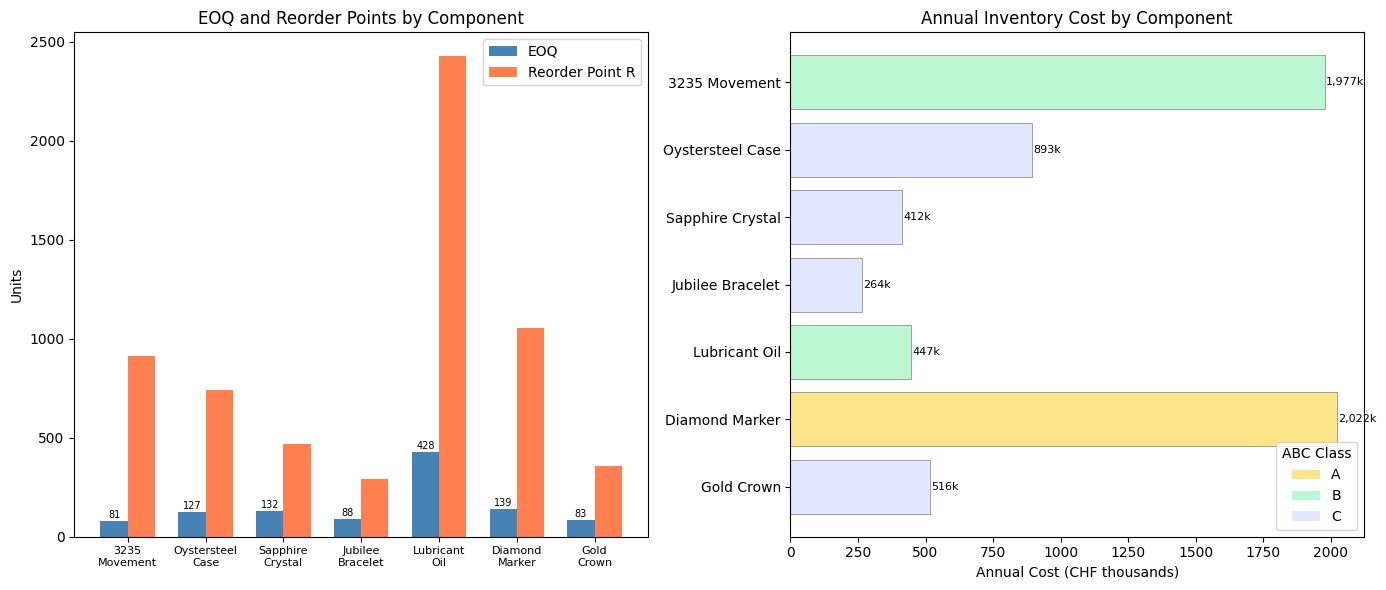

In [22]:
# ── Inventory Visualisation ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: EOQ and Reorder Points by component ────────────────────────────────
comp_labels = [c.replace(" ", "\n") for c in df_inv["Component"]]
x = np.arange(len(comp_labels))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, df_inv["EOQ"],               width=w, color="steelblue", label="EOQ")
b2 = ax.bar(x + w/2, df_inv["Reorder Point (R)"], width=w, color="coral",     label="Reorder Point R")
ax.set_xticks(x); ax.set_xticklabels(comp_labels, fontsize=8)
ax.set_ylabel("Units"); ax.set_title("EOQ and Reorder Points by Component")
ax.legend()

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=7)

# ── Right: Annual cost breakdown ──────────────────────────────────────────────
ax2 = axes[1]
colors_abc = {"A":"#fde68a","B":"#bbf7d0","C":"#e0e7ff"}
abc_map = dict(zip(df_policy["Component"], df_policy["ABC"]))
bar_colors = [colors_abc[abc_map[c]] for c in df_inv["Component"]]

bars = ax2.barh(df_inv["Component"], df_inv["Ann. Cost (CHF)"] / 1e3,
                color=bar_colors, edgecolor="grey", linewidth=0.5)
ax2.set_xlabel("Annual Cost (CHF thousands)")
ax2.set_title("Annual Inventory Cost by Component")
ax2.invert_yaxis()
for bar, val in zip(bars, df_inv["Ann. Cost (CHF)"]):
    ax2.text(bar.get_width() + 5, bar.get_y()+bar.get_height()/2,
             f"{val/1e3:,.0f}k", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#fde68a", label="A"),
              Patch(facecolor="#bbf7d0", label="B"),
              Patch(facecolor="#e0e7ff", label="C")]
ax2.legend(handles=legend_els, title="ABC Class", loc="lower right")

plt.tight_layout()
plt.show()


#**PART 2**

##LS-U


  MODEL LS-U — UNCAPACITATED LOT-SIZING

── Heritage ──


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,150,150,0,1,"1,200,000",0,"20,000","1,220,000"
1,Feb,140,140,0,1,"1,120,000",0,"20,000","1,140,000"
2,Mar,200,200,0,1,"1,600,000",0,"20,000","1,620,000"
3,Apr,220,220,0,1,"1,760,000",0,"20,000","1,780,000"
4,May,250,250,0,1,"2,000,000",0,"20,000","2,020,000"
5,Jun,300,300,0,1,"2,400,000",0,"20,000","2,420,000"
6,Jul,270,270,0,1,"2,160,000",0,"20,000","2,180,000"
7,Aug,250,250,0,1,"2,000,000",0,"20,000","2,020,000"
8,Sep,320,320,0,1,"2,560,000",0,"20,000","2,580,000"
9,Oct,400,400,0,1,"3,200,000",0,"20,000","3,220,000"



── Chronos ──


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,120,120,0,1,"1,440,000",0,"25,000","1,465,000"
1,Feb,130,130,0,1,"1,560,000",0,"25,000","1,585,000"
2,Mar,150,150,0,1,"1,800,000",0,"25,000","1,825,000"
3,Apr,180,180,0,1,"2,160,000",0,"25,000","2,185,000"
4,May,210,210,0,1,"2,520,000",0,"25,000","2,545,000"
5,Jun,240,240,0,1,"2,880,000",0,"25,000","2,905,000"
6,Jul,230,230,0,1,"2,760,000",0,"25,000","2,785,000"
7,Aug,210,210,0,1,"2,520,000",0,"25,000","2,545,000"
8,Sep,260,260,0,1,"3,120,000",0,"25,000","3,145,000"
9,Oct,300,300,0,1,"3,600,000",0,"25,000","3,625,000"



── Cost Summary (CHF) ──
  Status                : 1
  Total Prod Cost       :      59,360,000
  Total Hold Cost       :               0
  Total Setup Cost      :         540,000
  Grand Total           :      59,900,000


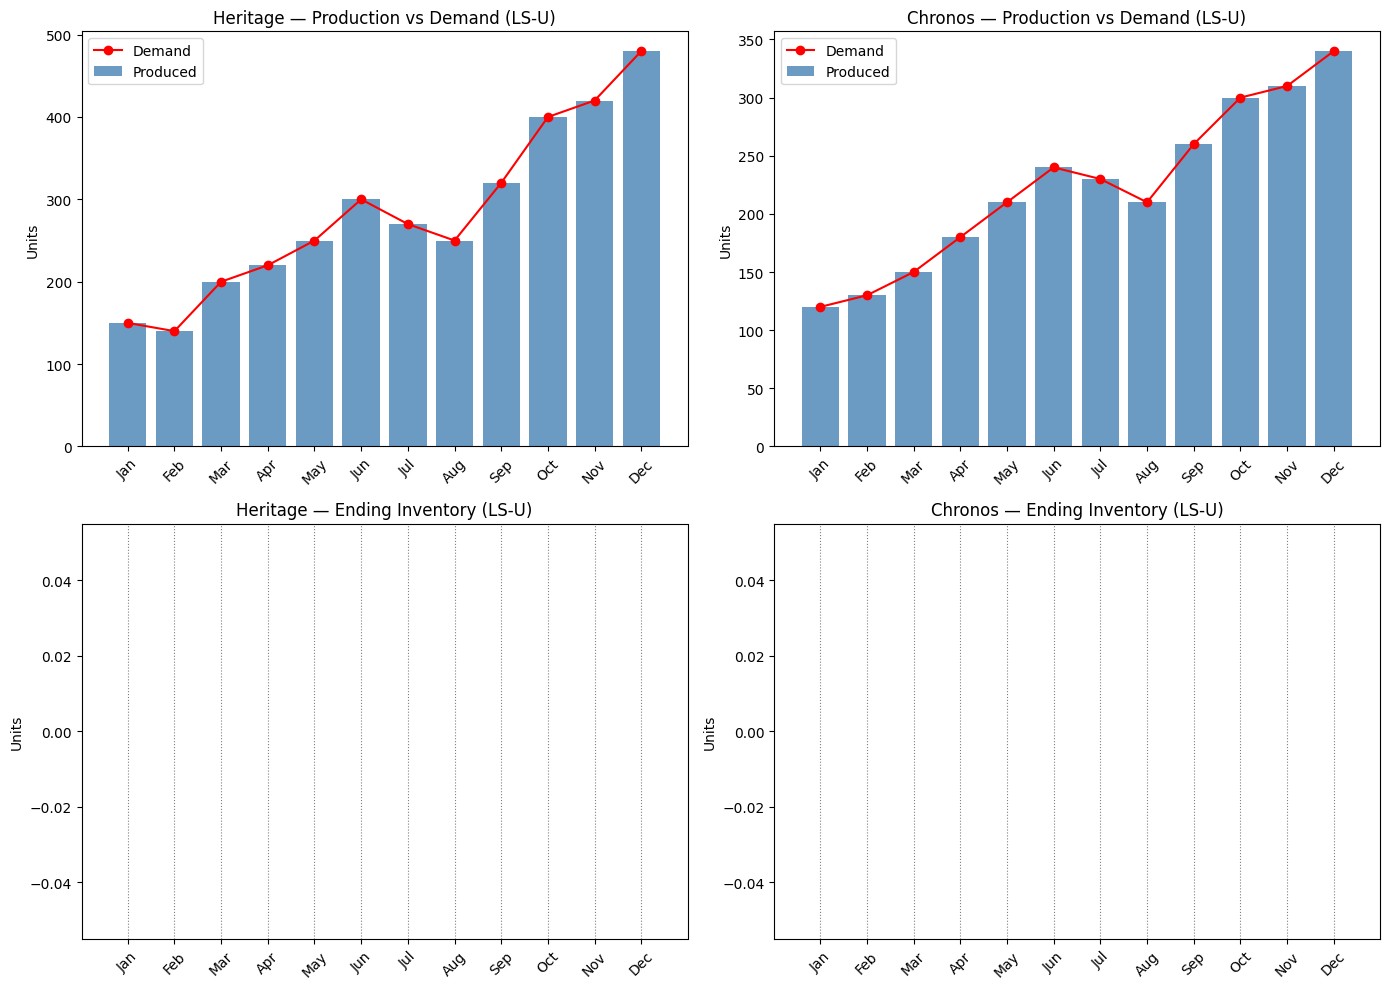

In [23]:
# ── Model LS-U: Uncapacitated Lot-Sizing (Heritage & Chronos) ────────────────
#
# Decision variables:
#   X[p,t] : production quantity of product p in month t  (continuous, >= 0)
#   I[p,t] : ending inventory of product p in month t     (continuous, >= 0)
#   Y[p,t] : binary setup indicator (1 = produce in month t)  in {0,1}
#
# Objective (minimise):
#   sum_{p,t}  prod_cost[p]    * X[p,t]
# + sum_{p,t}  holding_cost[p] * I[p,t]
# + sum_{p,t}  setup_cost[p]   * Y[p,t]
#
# Constraints:
#   Inventory balance : I[p,t] = I[p,t-1] + X[p,t] - d[p,t]   for all p, t
#   Setup linking     : X[p,t] <= M[p] * Y[p,t]                 for all p, t
#   Non-negativity    : X[p,t], I[p,t] >= 0 ;  Y[p,t] in {0,1}
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── Part 2 shared parameters ──────────────────────────────────────────────────
T2           = 12
MONTH_NAMES2 = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
products2    = ["Heritage", "Chronos"]

demand_p2 = {
    "Heritage": [150,140,200,220,250,300,270,250,320,400,420,480],
    "Chronos":  [120,130,150,180,210,240,230,210,260,300,310,340],
}

prod_cost2    = {"Heritage":  8000, "Chronos": 12000}
holding_cost2 = {"Heritage":   150, "Chronos":   200}
setup_cost2   = {"Heritage": 20000, "Chronos": 25000}

# Big-M: upper bound on production in a single period
BIG_M2 = {p: sum(demand_p2[p]) + 1 for p in products2}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_lsu(verbose=False):
    """
    Uncapacitated Lot-Sizing (LS-U) for Heritage and Chronos.
    No capacity constraint — optimises production, setup, and holding costs.
    """
    prob = LpProblem("Aurelius_LSU", LpMinimize)

    X = {(p,t): LpVariable(f"X_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    I = {(p,t): LpVariable(f"I_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    Y = {(p,t): LpVariable(f"Y_{p}_{t}", cat=LpBinary)
         for p in products2 for t in range(T2)}

    # Objective
    prob += (
        lpSum(prod_cost2[p]    * X[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p] * I[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p]   * Y[p,t] for p in products2 for t in range(T2))
    ), "Total_Cost"

    # Constraints
    for p in products2:
        for t in range(T2):
            prev_I = 0 if t == 0 else I[p, t-1]
            prob += I[p,t] == prev_I + X[p,t] - demand_p2[p][t], f"inv_{p}_{t}"
            prob += X[p,t] <= BIG_M2[p] * Y[p,t],                f"setup_{p}_{t}"

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # Extract results
    rows = []
    for p in products2:
        for t in range(T2):
            xv = value(X[p,t]); iv = value(I[p,t]); yv = value(Y[p,t])
            rows.append({
                "Product":    p,
                "Month":      MONTH_NAMES2[t],
                "Produced":   round(xv, 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(iv, 1),
                "Setup":      int(round(yv)),
                "Prod Cost":  prod_cost2[p]    * xv,
                "Hold Cost":  holding_cost2[p] * iv,
                "Setup Cost": setup_cost2[p]   * yv,
            })
    df = pd.DataFrame(rows)
    df["Total Cost"] = df["Prod Cost"] + df["Hold Cost"] + df["Setup Cost"]

    summary = {
        "Status":           prob.status,
        "Total Prod Cost":  sum(prod_cost2[p]    * value(X[p,t]) for p in products2 for t in range(T2)),
        "Total Hold Cost":  sum(holding_cost2[p] * value(I[p,t]) for p in products2 for t in range(T2)),
        "Total Setup Cost": sum(setup_cost2[p]   * value(Y[p,t]) for p in products2 for t in range(T2)),
        "Grand Total":      value(prob.objective),
    }
    return df, summary


# ── Run & display ─────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.0f}".format)

df_lsu, s_lsu = solve_lsu()

print(f"\n{'='*60}")
print(f"  MODEL LS-U — UNCAPACITATED LOT-SIZING")
print(f"{'='*60}")

for p in products2:
    print(f"\n── {p} ──")
    sub = df_lsu[df_lsu["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_lsu.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = range(T2)

for idx, p in enumerate(products2):
    sub = df_lsu[df_lsu["Product"] == p].reset_index(drop=True)

    ax = axes[0, idx]
    ax.bar(x, sub["Produced"], color="steelblue", label="Produced", alpha=0.8)
    ax.plot(x, sub["Demand"],  "ro-", label="Demand", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production vs Demand (LS-U)")
    ax.legend()

    ax2 = axes[1, idx]
    ax2.bar(x, sub["End Inv"], color="coral", alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Ending Inventory (LS-U)")
    for t in range(T2):
        if sub.loc[t, "Setup"] == 1:
            ax2.axvline(t, color="grey", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

##LS-C


  MODEL LS-C — CAPACITATED LOT-SIZING

── Heritage ──


,Month,Produced,Demand,End Inv,Setup,Peak (2x),Hrs Used,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,150,150,0,1,No,"1,225","1,200,000",0,"20,000","1,220,000"
1,Feb,140,140,0,1,No,"1,145","1,120,000",0,"20,000","1,140,000"
2,Mar,200,200,0,1,No,"1,625","1,600,000",0,"20,000","1,620,000"
3,Apr,220,220,0,1,No,"1,785","1,760,000",0,"20,000","1,780,000"
4,May,550,250,300,1,No,"4,425","4,400,000","45,000","20,000","4,465,000"
5,Jun,0,300,0,0,Yes,0,0,0,0,0
6,Jul,270,270,0,1,No,"2,185","2,160,000",0,"20,000","2,180,000"
7,Aug,250,250,0,1,No,"2,025","2,000,000",0,"20,000","2,020,000"
8,Sep,720,320,400,1,No,"5,785","5,760,000","60,000","20,000","5,840,000"
9,Oct,0,400,0,0,Yes,0,0,0,0,0



── Chronos ──


,Month,Produced,Demand,End Inv,Setup,Peak (2x),Hrs Used,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,120,120,0,1,No,"1,470","1,440,000",0,"25,000","1,465,000"
1,Feb,130,130,0,1,No,"1,590","1,560,000",0,"25,000","1,585,000"
2,Mar,150,150,0,1,No,"1,830","1,800,000",0,"25,000","1,825,000"
3,Apr,180,180,0,1,No,"2,190","2,160,000",0,"25,000","2,185,000"
4,May,450,210,240,1,No,"5,430","5,400,000","48,000","25,000","5,473,000"
5,Jun,0,240,0,0,Yes,0,0,0,0,0
6,Jul,230,230,0,1,No,"2,790","2,760,000",0,"25,000","2,785,000"
7,Aug,210,210,0,1,No,"2,550","2,520,000",0,"25,000","2,545,000"
8,Sep,560,260,300,1,No,"6,750","6,720,000","60,000","25,000","6,805,000"
9,Oct,0,300,0,0,Yes,0,0,0,0,0



── Monthly Capacity Utilisation ──


,Month,Total Hrs Used,Capacity,Utilisation %
0,Jan,"2,695",18000,15
1,Feb,"2,735",18000,15
2,Mar,"3,455",18000,19
3,Apr,"3,975",18000,22
4,May,"9,855",18000,55
5,Jun,0,18000,0
6,Jul,"4,975",18000,28
7,Aug,"4,575",18000,25
8,Sep,"12,535",18000,70
9,Oct,0,18000,0



── Cost Summary (CHF) ──
  Status                : 1
  Total Prod Cost       :      59,360,000
  Total Hold Cost       :         353,000
  Total Setup Cost      :         405,000
  Grand Total           :      60,118,000

── LS-U vs LS-C Grand Total ──
  LS-U :      59,900,000 CHF
  LS-C :      60,118,000 CHF
  Diff :         218,000 CHF  (capacity + peak premium)


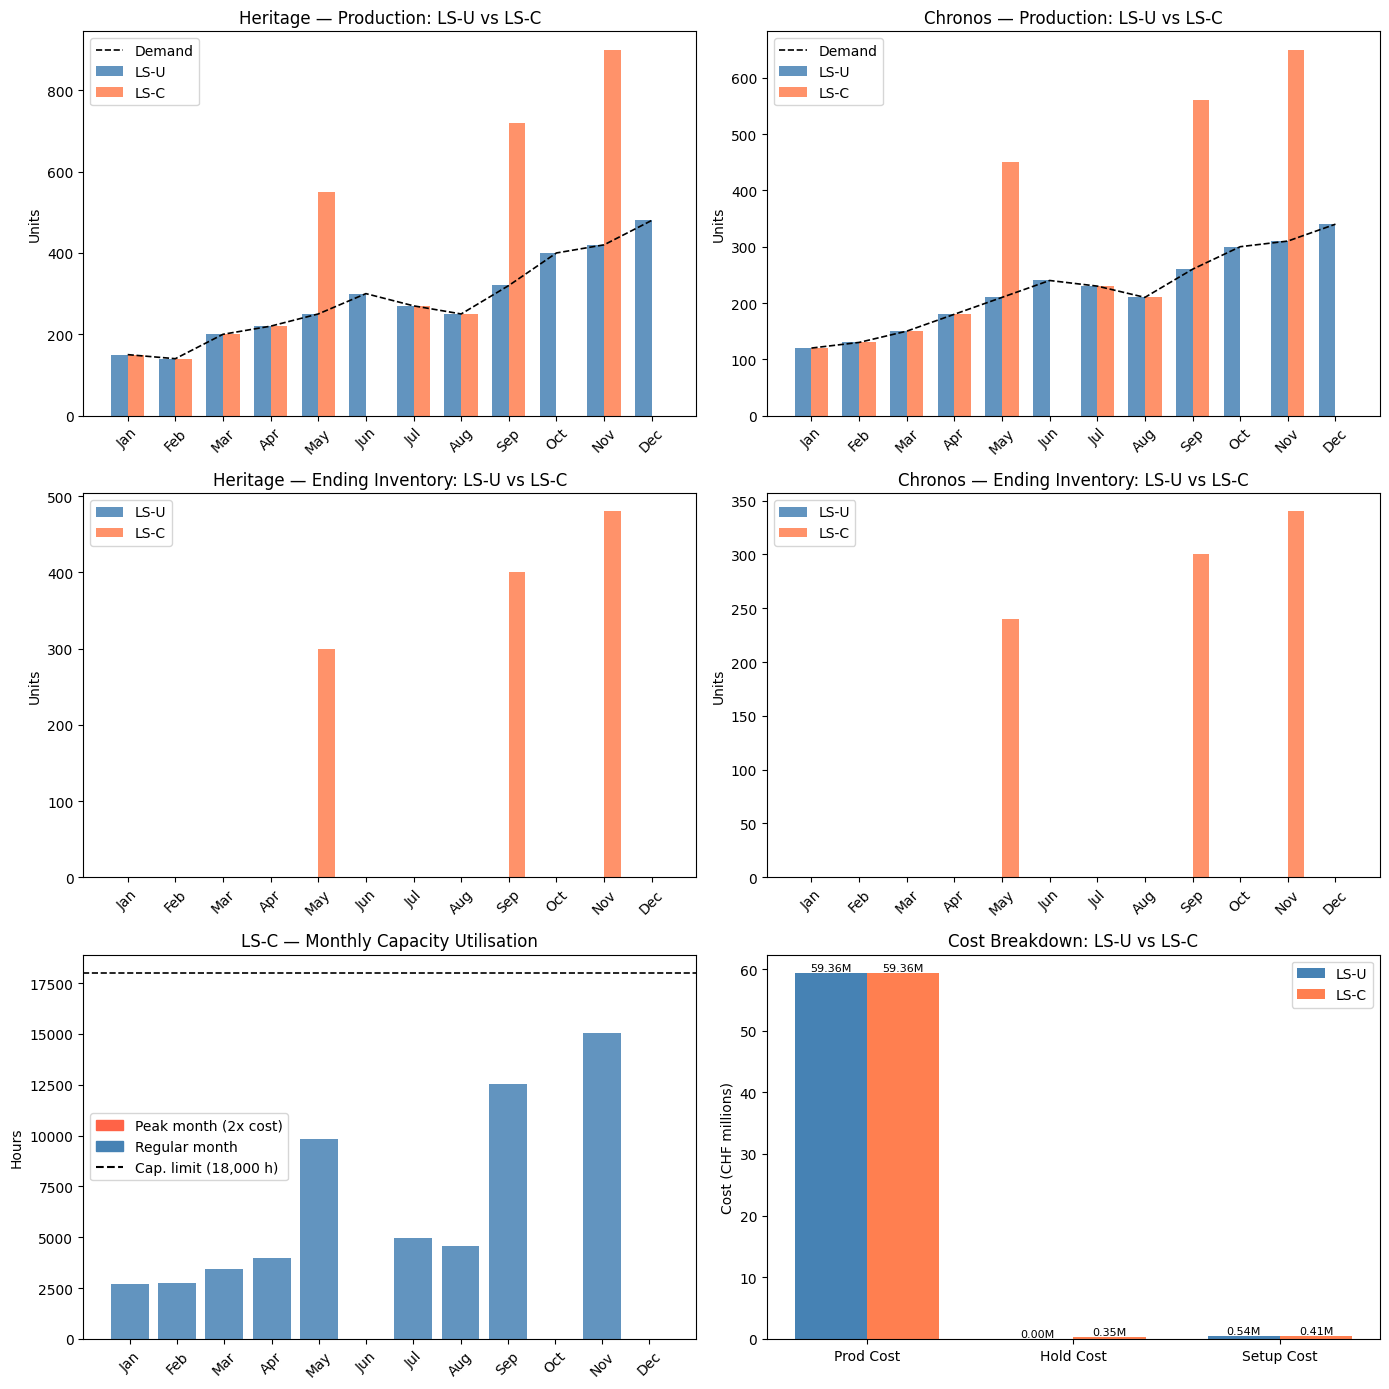

In [24]:
# ── Model LS-C: Capacitated Lot-Sizing (Heritage & Chronos) ──────────────────
#
# Extends LS-U with:
#   1. Capacity constraint: total machine-hours per month <= 18 000 h
#      Heritage: 8 h/unit + 25 h/setup ; Chronos: 12 h/unit + 30 h/setup
#   2. Peak-time cost multiplier alpha[t] = 2 in June, October, December
#      (production & setup costs doubled in those months)
#
# Objective (minimise):
#   sum_{p,t}  alpha[t] * prod_cost[p]  * X[p,t]
# + sum_{p,t}  holding_cost[p] * I[p,t]
# + sum_{p,t}  alpha[t] * setup_cost[p] * Y[p,t]
#
# Additional capacity constraint (for all t):
#   sum_p ( prod_hrs[p]*X[p,t] + setup_hrs[p]*Y[p,t] ) <= 18000
# ─────────────────────────────────────────────────────────────────────────────

from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── Capacity & peak parameters ────────────────────────────────────────────────
CAP_HOURS       = 18000
prod_hrs        = {"Heritage": 8,  "Chronos": 12}
setup_hrs       = {"Heritage": 25, "Chronos": 30}
peak_months_set = {6, 10, 12}   # 1-indexed; Jun, Oct, Dec
peak_mult       = {t: (2 if (t + 1) in peak_months_set else 1) for t in range(T2)}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_lsc(verbose=False):
    """
    Capacitated Lot-Sizing (LS-C) for Heritage and Chronos.
    18 000 h/month capacity constraint; 2x costs in June, October, December.
    """
    prob = LpProblem("Aurelius_LSC", LpMinimize)

    X = {(p,t): LpVariable(f"X_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    I = {(p,t): LpVariable(f"I_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    Y = {(p,t): LpVariable(f"Y_{p}_{t}", cat=LpBinary)
         for p in products2 for t in range(T2)}

    # Objective — production & setup costs scaled by peak multiplier
    prob += (
        lpSum(prod_cost2[p]  * peak_mult[t] * X[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p]              * I[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p] * peak_mult[t] * Y[p,t] for p in products2 for t in range(T2))
    ), "Total_Cost"

    for p in products2:
        for t in range(T2):
            prev_I = 0 if t == 0 else I[p, t-1]
            prob += I[p,t] == prev_I + X[p,t] - demand_p2[p][t], f"inv_{p}_{t}"
            prob += X[p,t] <= BIG_M2[p] * Y[p,t],                f"setup_{p}_{t}"

    # Capacity constraint
    for t in range(T2):
        prob += (
            lpSum(prod_hrs[p] * X[p,t] + setup_hrs[p] * Y[p,t] for p in products2)
            <= CAP_HOURS,
            f"capacity_{t}"
        )

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # Extract results
    rows = []
    for p in products2:
        for t in range(T2):
            xv = value(X[p,t]); iv = value(I[p,t]); yv = value(Y[p,t])
            pm = peak_mult[t]
            hrs = prod_hrs[p] * xv + setup_hrs[p] * yv
            rows.append({
                "Product":    p,
                "Month":      MONTH_NAMES2[t],
                "Produced":   round(xv, 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(iv, 1),
                "Setup":      int(round(yv)),
                "Peak (2x)": "Yes" if pm == 2 else "No",
                "Hrs Used":   round(hrs, 1),
                "Prod Cost":  prod_cost2[p]  * pm * xv,
                "Hold Cost":  holding_cost2[p]    * iv,
                "Setup Cost": setup_cost2[p] * pm * yv,
            })
    df = pd.DataFrame(rows)
    df["Total Cost"] = df["Prod Cost"] + df["Hold Cost"] + df["Setup Cost"]

    df_hrs = (
        df.groupby("Month")["Hrs Used"].sum()
          .reindex(MONTH_NAMES2).reset_index()
    )
    df_hrs.columns = ["Month", "Total Hrs Used"]

    summary = {
        "Status":           prob.status,
        "Total Prod Cost":  sum(prod_cost2[p]    * peak_mult[t] * value(X[p,t]) for p in products2 for t in range(T2)),
        "Total Hold Cost":  sum(holding_cost2[p]               * value(I[p,t]) for p in products2 for t in range(T2)),
        "Total Setup Cost": sum(setup_cost2[p]   * peak_mult[t] * value(Y[p,t]) for p in products2 for t in range(T2)),
        "Grand Total":      value(prob.objective),
    }
    return df, df_hrs, summary


# ── Run & display ─────────────────────────────────────────────────────────────
df_lsc, df_hours, s_lsc = solve_lsc()

print(f"\n{'='*60}")
print(f"  MODEL LS-C — CAPACITATED LOT-SIZING")
print(f"{'='*60}")

for p in products2:
    print(f"\n── {p} ──")
    sub = df_lsc[df_lsc["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print("\n── Monthly Capacity Utilisation ──")
df_cap = df_hours.copy()
df_cap["Capacity"]      = CAP_HOURS
df_cap["Utilisation %"] = (df_cap["Total Hrs Used"] / CAP_HOURS * 100).round(1)
display(df_cap)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_lsc.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")

print(f"\n── LS-U vs LS-C Grand Total ──")
print(f"  LS-U : {s_lsu['Grand Total']:>15,.0f} CHF")
print(f"  LS-C : {s_lsc['Grand Total']:>15,.0f} CHF")
print(f"  Diff : {s_lsc['Grand Total'] - s_lsu['Grand Total']:>15,.0f} CHF  (capacity + peak premium)")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
x  = range(T2)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

for idx, p in enumerate(products2):
    sub_u = df_lsu[df_lsu["Product"] == p].reset_index(drop=True)
    sub_c = df_lsc[df_lsc["Product"] == p].reset_index(drop=True)

    # Production: LS-U vs LS-C
    ax = axes[0, idx]
    ax.bar(x1, sub_u["Produced"], width=w, color="steelblue", label="LS-U", alpha=0.85)
    ax.bar(x2, sub_c["Produced"], width=w, color="coral",     label="LS-C", alpha=0.85)
    ax.plot(x, sub_u["Demand"], "k--", linewidth=1.2, label="Demand")
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production: LS-U vs LS-C")
    ax.legend()

    # Inventory: LS-U vs LS-C
    ax2 = axes[1, idx]
    ax2.bar(x1, sub_u["End Inv"], width=w, color="steelblue", label="LS-U", alpha=0.85)
    ax2.bar(x2, sub_c["End Inv"], width=w, color="coral",     label="LS-C", alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Ending Inventory: LS-U vs LS-C")
    ax2.legend()

# Capacity utilisation
ax3 = axes[2, 0]
bar_cols = ["tomato" if (i+1) in peak_months_set else "steelblue" for i in range(T2)]
ax3.bar(x, df_hours["Total Hrs Used"], color=bar_cols, alpha=0.85)
ax3.axhline(CAP_HOURS, color="black", linestyle="--", linewidth=1.2)
ax3.set_xticks(x); ax3.set_xticklabels(MONTH_NAMES2, rotation=45)
ax3.set_ylabel("Hours"); ax3.set_title("LS-C — Monthly Capacity Utilisation")
peak_patch = mpatches.Patch(color="tomato",    label="Peak month (2x cost)")
reg_patch  = mpatches.Patch(color="steelblue", label="Regular month")
cap_line   = plt.Line2D([0],[0], color="black", linestyle="--", label=f"Cap. limit ({CAP_HOURS:,} h)")
ax3.legend(handles=[peak_patch, reg_patch, cap_line])

# Cost breakdown bar
ax4 = axes[2, 1]
cats  = ["Prod Cost", "Hold Cost", "Setup Cost"]
lsu_v = [s_lsu["Total Prod Cost"], s_lsu["Total Hold Cost"], s_lsu["Total Setup Cost"]]
lsc_v = [s_lsc["Total Prod Cost"], s_lsc["Total Hold Cost"], s_lsc["Total Setup Cost"]]
xi    = np.arange(len(cats))
b1 = ax4.bar(xi - w/2, [v/1e6 for v in lsu_v], w, color="steelblue", label="LS-U")
b2 = ax4.bar(xi + w/2, [v/1e6 for v in lsc_v], w, color="coral",     label="LS-C")
for bar in list(b1) + list(b2):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)
ax4.set_xticks(xi); ax4.set_xticklabels(cats)
ax4.set_ylabel("Cost (CHF millions)"); ax4.set_title("Cost Breakdown: LS-U vs LS-C")
ax4.legend()

plt.tight_layout()
plt.show()


##MRP


  MRP MODEL — MULTI-LEVEL MATERIAL REQUIREMENTS PLANNING

── Finished Goods Production Plan ──

   Heritage


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,490,150,340,1,"3,920,000","51,000","20,000","3,991,000"
1,Feb,0,140,200,0,0,"30,000",0,"30,000"
2,Mar,0,200,0,0,0,0,0,0
3,Apr,470,220,250,1,"3,760,000","37,500","20,000","3,817,500"
4,May,0,250,0,0,0,0,0,0
5,Jun,820,300,520,1,"6,560,000","78,000","20,000","6,658,000"
6,Jul,0,270,250,0,0,"37,500",0,"37,500"
7,Aug,0,250,0,0,0,0,0,0
8,Sep,720,320,400,1,"5,760,000","60,000","20,000","5,840,000"
9,Oct,0,400,0,0,0,0,0,0



   Chronos


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,400,120,280,1,"4,800,000","56,000","25,000","4,881,000"
1,Feb,0,130,150,0,0,"30,000",0,"30,000"
2,Mar,0,150,0,0,0,0,0,0
3,Apr,390,180,210,1,"4,680,000","42,000","25,000","4,747,000"
4,May,0,210,0,0,0,0,0,0
5,Jun,680,240,440,1,"8,160,000","88,000","25,000","8,273,000"
6,Jul,0,230,210,0,0,"42,000",0,"42,000"
7,Aug,0,210,0,0,0,0,0,0
8,Sep,560,260,300,1,"6,720,000","60,000","25,000","6,805,000"
9,Oct,0,300,0,0,0,0,0,0



── Component Order & Inventory Plan ──

   3235 Movement  (LT: 2 mo, Init. stock: 900)


...


   Lubricant Oil  (LT: 1 mo, Init. stock: 5,500)


,Month,Order Placed,End Inv,Hold Cost
0,Jan,0,0,0
1,Feb,0,0,0
2,Mar,"8,600",0,0
3,Apr,0,0,0
4,May,"15,000",0,0
5,Jun,0,0,0
6,Jul,0,0,0
7,Aug,"12,800",0,0
8,Sep,0,0,0
9,Oct,"15,500",0,0



   Gold Crown  (LT: 1 mo, Init. stock: 300)


,Month,Order Placed,End Inv,Hold Cost
0,Jan,0,0,0
1,Feb,0,0,0
2,Mar,470,0,0
3,Apr,0,0,0
4,May,820,0,0
5,Jun,0,0,0
6,Jul,0,0,0
7,Aug,720,0,0
8,Sep,0,0,0
9,Oct,900,0,0



── Cost Summary (CHF) ──
  Status                : 1
  FG Prod Cost          :      59,360,000
  FG Hold Cost          :         752,000
  FG Setup Cost         :         225,000
  Comp Proc Cost        :      68,190,000
  Comp Hold Cost        :         135,720
  Comp Setup Cost       :         840,000
  Grand Total           :     129,502,720

── External Demand Trade-off (Oystersteel Case) ──
  Total external demand months 1-6: 118 units
  All external demand is satisfied by the MRP plan.
  Component orders are front-loaded to buffer both internal assembly
  and external client requirements without shortages.


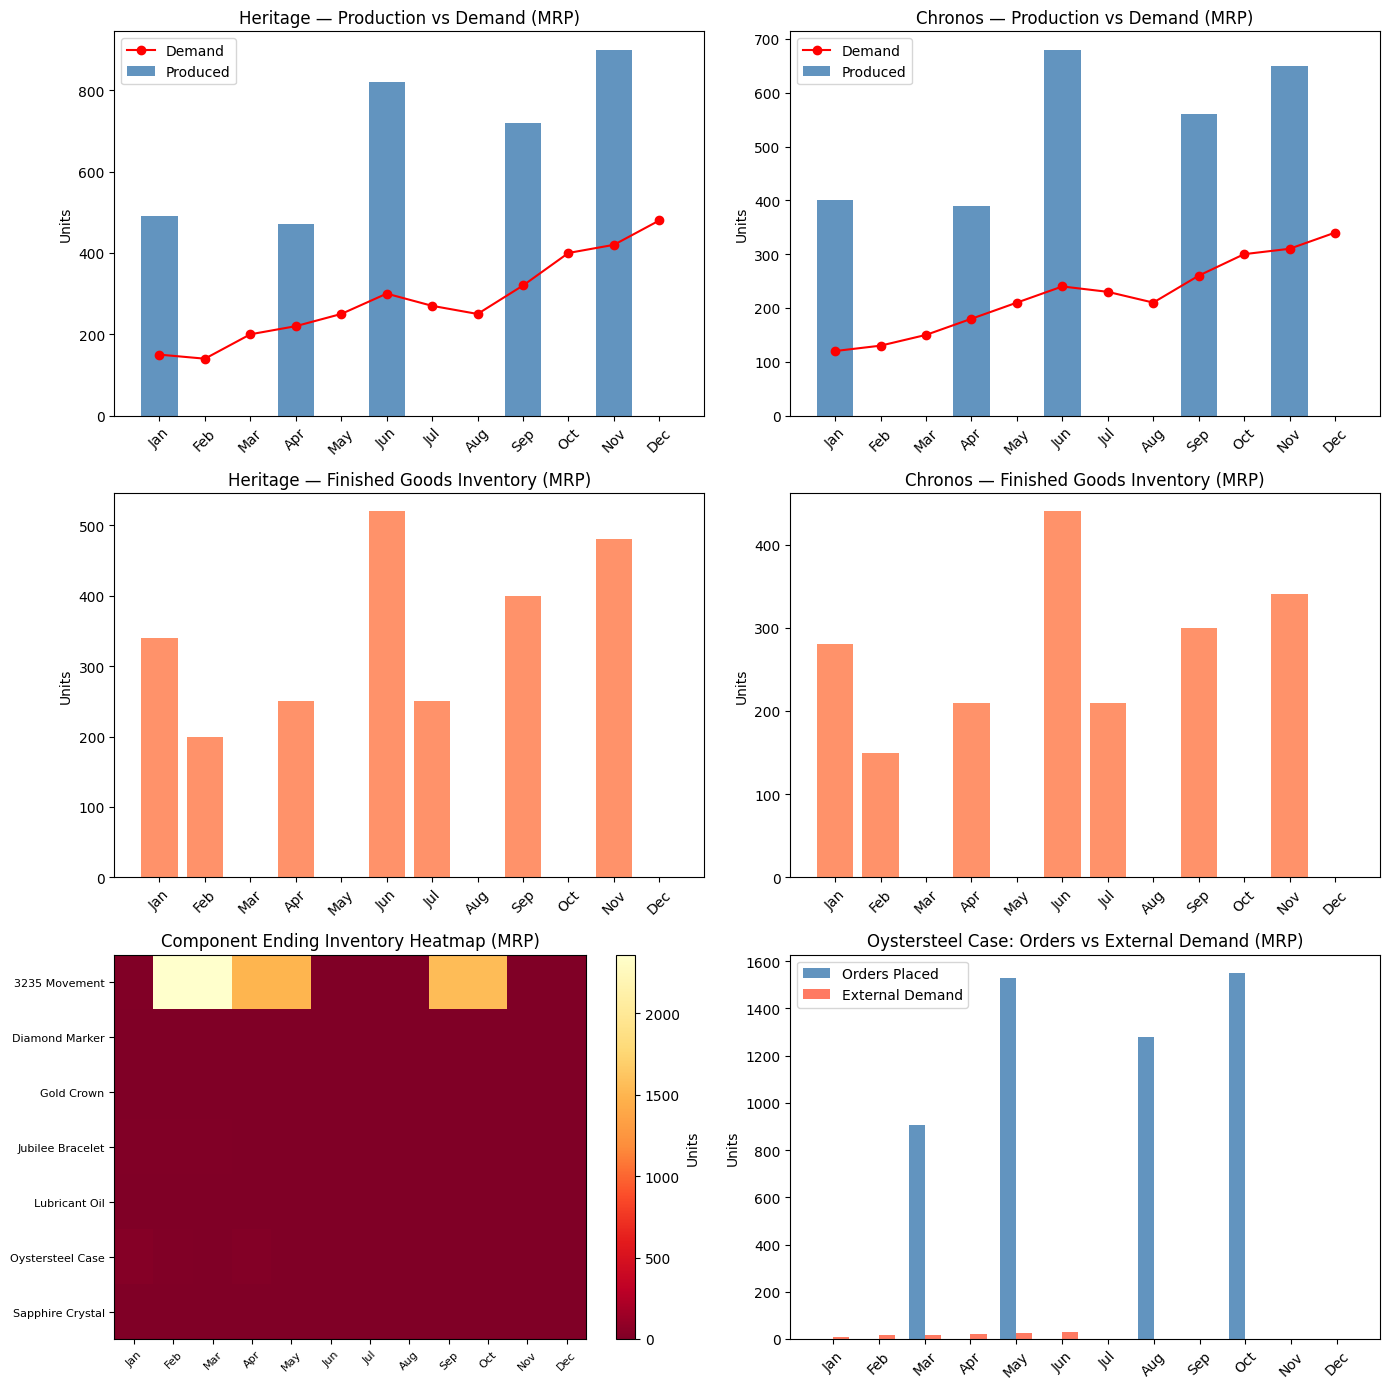

In [25]:
# ── MRP Model: Multi-Level Material Requirements Planning ────────────────────
#
# Simultaneously plans finished goods (Heritage, Chronos) AND all 7 components
# from the Bill of Materials, respecting lead times, initial inventories,
# and external demand for Oystersteel Cases (months 1-6).
#
# Decision variables:
#   Xfg[p,t]  : finished-good production quantity            (>= 0)
#   Ifg[p,t]  : finished-good ending inventory               (>= 0)
#   Yfg[p,t]  : binary setup for finished good               (in {0,1})
#   Qc[c,t]   : component order qty placed in month t        (>= 0)
#   Ic[c,t]   : component ending inventory                   (>= 0)
#   Yc[c,t]   : binary setup for component order             (in {0,1})
#
# Key component inventory balance:
#   Ic[c,t] = Ic[c,t-1] + Qc[c, t-LT_c] - sum_p bom[c,p]*Xfg[p,t] - ext[c,t]
#   (order placed LT_c months ago arrives and is consumed this period)
# ─────────────────────────────────────────────────────────────────────────────

from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── BOM & component parameters ────────────────────────────────────────────────
bom = {
    "3235 Movement":    {"Heritage": 1,  "Chronos":  1},
    "Oystersteel Case": {"Heritage": 1,  "Chronos":  1},
    "Sapphire Crystal": {"Heritage": 1,  "Chronos":  1},
    "Jubilee Bracelet": {"Heritage": 1,  "Chronos":  0},
    "Diamond Marker":   {"Heritage": 0,  "Chronos":  8},
    "Lubricant Oil":    {"Heritage": 10, "Chronos": 10},  # 10-gram units
    "Gold Crown":       {"Heritage": 1,  "Chronos":  0},
}

lead_time_mo = {
    "3235 Movement": 2, "Oystersteel Case": 1, "Sapphire Crystal": 1,
    "Jubilee Bracelet": 2, "Diamond Marker": 2, "Lubricant Oil": 1, "Gold Crown": 1,
}

init_stock = {
    "3235 Movement": 900, "Oystersteel Case": 550, "Sapphire Crystal": 550,
    "Jubilee Bracelet": 500, "Diamond Marker": 3200, "Lubricant Oil": 5500,
    "Gold Crown": 300,
}

comp_prod_cost2    = {
    "3235 Movement": 6500, "Oystersteel Case": 2000, "Sapphire Crystal": 1500,
    "Jubilee Bracelet": 1800, "Diamond Marker": 400, "Lubricant Oil": 10,
    "Gold Crown": 600,
}
comp_holding_cost2 = {
    "3235 Movement": 12, "Oystersteel Case": 60, "Sapphire Crystal": 80,
    "Jubilee Bracelet": 40, "Diamond Marker": 25, "Lubricant Oil": 3,
    "Gold Crown": 20,
}
comp_setup_cost2   = {
    "3235 Movement": 80000, "Oystersteel Case": 50000, "Sapphire Crystal": 50000,
    "Jubilee Bracelet": 35000, "Diamond Marker": 20000, "Lubricant Oil": 10000,
    "Gold Crown": 25000,
}

# External demand for Oystersteel Cases (months 1-6; 0 thereafter)
ext_demand_oyster  = [10, 15, 18, 22, 25, 28] + [0] * 6

components = list(bom.keys())
max_lt     = max(lead_time_mo.values())   # = 2

# Big-M for finished goods and components
BIG_M_fg = {p: sum(demand_p2[p]) + 1 for p in products2}
BIG_M_c  = {
    c: sum(bom[c][p] * sum(demand_p2[p]) for p in products2 if bom[c][p] > 0)
       + init_stock[c] + 1
    for c in components
}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_mrp(verbose=False):
    """
    Full multi-level MRP MILP.
    Orders are placed from index -1 onward so 2-month-lead-time components
    can be ordered in month -1 and arrive ready for month 1 consumption.
    """
    prob = LpProblem("Aurelius_MRP", LpMinimize)

    # Order range: allows negative indices for pre-horizon orders
    order_range = range(-max_lt + 1, T2)   # -1, 0, ..., 11

    # ── Decision variables ────────────────────────────────────────────────────
    Xfg = {(p,t): LpVariable(f"Xfg_{p}_{t}", lowBound=0)
           for p in products2 for t in range(T2)}
    Ifg = {(p,t): LpVariable(f"Ifg_{p}_{t}", lowBound=0)
           for p in products2 for t in range(T2)}
    Yfg = {(p,t): LpVariable(f"Yfg_{p}_{t}", cat=LpBinary)
           for p in products2 for t in range(T2)}

    Qc  = {(c,t): LpVariable(f"Q_{c}_{t}", lowBound=0)
           for c in components for t in order_range}
    Ic  = {(c,t): LpVariable(f"Ic_{c}_{t}", lowBound=0)
           for c in components for t in range(T2)}
    Yc  = {(c,t): LpVariable(f"Yc_{c}_{t}", cat=LpBinary)
           for c in components for t in order_range}

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        # Finished goods
        lpSum(prod_cost2[p]    * Xfg[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p] * Ifg[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p]   * Yfg[p,t] for p in products2 for t in range(T2))
        # Components
      + lpSum(comp_prod_cost2[c]    * Qc[c,t]  for c in components for t in order_range)
      + lpSum(comp_holding_cost2[c] * Ic[c,t]  for c in components for t in range(T2))
      + lpSum(comp_setup_cost2[c]   * Yc[c,t]  for c in components for t in order_range)
    ), "Total_Cost"

    # ── Finished goods constraints ────────────────────────────────────────────
    for p in products2:
        for t in range(T2):
            prev_Ifg = 0 if t == 0 else Ifg[p, t-1]
            prob += Ifg[p,t] == prev_Ifg + Xfg[p,t] - demand_p2[p][t], f"inv_fg_{p}_{t}"
            prob += Xfg[p,t] <= BIG_M_fg[p] * Yfg[p,t],               f"setup_fg_{p}_{t}"

    # ── Component constraints ─────────────────────────────────────────────────
    for c in components:
        lt = lead_time_mo[c]
        for t in range(T2):
            # Dependent demand: BOM * finished-good production this period
            gross_req = lpSum(bom[c][p] * Xfg[p,t] for p in products2)
            # External demand (Oystersteel only)
            ext = ext_demand_oyster[t] if c == "Oystersteel Case" else 0
            # Receipt from order placed lt months ago
            ord_idx = t - lt
            receipt = Qc[c, ord_idx] if ord_idx in order_range else 0
            # Inventory balance
            prev_Ic = init_stock[c] if t == 0 else Ic[c, t-1]
            prob += Ic[c,t] == prev_Ic + receipt - gross_req - ext, f"inv_comp_{c}_{t}"
            # Setup linking for orders placed this period
            if t in order_range:
                prob += Qc[c,t] <= BIG_M_c[c] * Yc[c,t], f"setup_comp_{c}_{t}"

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract finished goods results ────────────────────────────────────────
    fg_rows = []
    for p in products2:
        for t in range(T2):
            fg_rows.append({
                "Product":    p, "Month": MONTH_NAMES2[t],
                "Produced":   round(value(Xfg[p,t]), 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(value(Ifg[p,t]), 1),
                "Setup":      int(round(value(Yfg[p,t]))),
                "Prod Cost":  prod_cost2[p]    * value(Xfg[p,t]),
                "Hold Cost":  holding_cost2[p] * value(Ifg[p,t]),
                "Setup Cost": setup_cost2[p]   * value(Yfg[p,t]),
            })
    df_fg = pd.DataFrame(fg_rows)
    df_fg["Total Cost"] = df_fg["Prod Cost"] + df_fg["Hold Cost"] + df_fg["Setup Cost"]

    # ── Extract component results ─────────────────────────────────────────────
    comp_rows = []
    for c in components:
        for t in range(T2):
            q_val = value(Qc[c, t]) if t in order_range else 0.0
            comp_rows.append({
                "Component":    c, "Month": MONTH_NAMES2[t],
                "Order Placed": round(q_val, 1),
                "End Inv":      round(value(Ic[c, t]), 1),
                "Hold Cost":    comp_holding_cost2[c] * value(Ic[c, t]),
            })
    df_comp = pd.DataFrame(comp_rows)

    summary = {
        "Status":           prob.status,
        "FG Prod Cost":     sum(prod_cost2[p]         * value(Xfg[p,t]) for p in products2  for t in range(T2)),
        "FG Hold Cost":     sum(holding_cost2[p]      * value(Ifg[p,t]) for p in products2  for t in range(T2)),
        "FG Setup Cost":    sum(setup_cost2[p]        * value(Yfg[p,t]) for p in products2  for t in range(T2)),
        "Comp Proc Cost":   sum(comp_prod_cost2[c]    * value(Qc[c,t])  for c in components for t in order_range),
        "Comp Hold Cost":   sum(comp_holding_cost2[c] * value(Ic[c,t])  for c in components for t in range(T2)),
        "Comp Setup Cost":  sum(comp_setup_cost2[c]   * value(Yc[c,t])  for c in components for t in order_range),
        "Grand Total":      value(prob.objective),
    }
    return df_fg, df_comp, summary


# ── Run & display ─────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.0f}".format)

df_fg_mrp, df_comp_mrp, s_mrp = solve_mrp()

print(f"\n{'='*60}")
print(f"  MRP MODEL — MULTI-LEVEL MATERIAL REQUIREMENTS PLANNING")
print(f"{'='*60}")

print("\n── Finished Goods Production Plan ──")
for p in products2:
    print(f"\n   {p}")
    sub = df_fg_mrp[df_fg_mrp["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print("\n── Component Order & Inventory Plan ──")
for c in components:
    lt = lead_time_mo[c]; s0 = init_stock[c]
    print(f"\n   {c}  (LT: {lt} mo, Init. stock: {s0:,})")
    sub = df_comp_mrp[df_comp_mrp["Component"] == c].drop(columns="Component").reset_index(drop=True)
    display(sub)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_mrp.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")

print(f"\n── External Demand Trade-off (Oystersteel Case) ──")
print(f"  Total external demand months 1-6: {sum(ext_demand_oyster)} units")
print(f"  All external demand is satisfied by the MRP plan.")
print(f"  Component orders are front-loaded to buffer both internal assembly")
print(f"  and external client requirements without shortages.")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
x = range(T2)
w = 0.35

# FG production & inventory
for idx, p in enumerate(products2):
    sub = df_fg_mrp[df_fg_mrp["Product"] == p].reset_index(drop=True)

    ax = axes[0, idx]
    ax.bar(x, sub["Produced"], color="steelblue", alpha=0.85, label="Produced")
    ax.plot(x, sub["Demand"],  "ro-", linewidth=1.5, label="Demand")
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production vs Demand (MRP)")
    ax.legend()

    ax2 = axes[1, idx]
    ax2.bar(x, sub["End Inv"], color="coral", alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Finished Goods Inventory (MRP)")

# Component inventory heatmap
ax3 = axes[2, 0]
pivot = df_comp_mrp.pivot(index="Component", columns="Month", values="End Inv")[MONTH_NAMES2]
im = ax3.imshow(pivot.values, aspect="auto", cmap="YlOrRd_r")
ax3.set_xticks(range(T2)); ax3.set_xticklabels(MONTH_NAMES2, rotation=45, fontsize=8)
ax3.set_yticks(range(len(components))); ax3.set_yticklabels(pivot.index, fontsize=8)
ax3.set_title("Component Ending Inventory Heatmap (MRP)")
plt.colorbar(im, ax=ax3, label="Units")

# Oystersteel: orders placed vs external demand
ax4 = axes[2, 1]
oyster = df_comp_mrp[df_comp_mrp["Component"] == "Oystersteel Case"].reset_index(drop=True)
x1c = [i - w/2 for i in x]; x2c = [i + w/2 for i in x]
ax4.bar(x1c, oyster["Order Placed"], width=w, color="steelblue", alpha=0.85, label="Orders Placed")
ax4.bar(x2c, ext_demand_oyster,      width=w, color="tomato",    alpha=0.85, label="External Demand")
ax4.set_xticks(x); ax4.set_xticklabels(MONTH_NAMES2, rotation=45)
ax4.set_ylabel("Units"); ax4.set_title("Oystersteel Case: Orders vs External Demand (MRP)")
ax4.legend()

plt.tight_layout()
plt.show()
